In [99]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [100]:
# List of models again
models = ["mobilenetv2", "resnet18", "densenet121", "vgg16", "vit-tiny",
               "efficientnet-b0", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "convnext-tiny", "ghostnetv2", "tinynet-a"]

linear_metrics = ["accuracy", "precision",  "recall", "auc"]
boxplot_metrics = ["cross_entropy_loss", "mae_loss", "mse_loss"]
barplot_metrics = ["f1_score", "r2_score", "latency", "max_malloc", "size"]

In [101]:
def load_metrics_csv(mode):
    # to store all dfs from the csv files
    dfs = []

    # Load data from all CSVs
    for model in models:
        # Load CSV in individual dataframe
        csv_file = glob.glob(f"metrics/pytorch/{mode}_metrics_{model}_BENCHMARK*.csv")[0]
        
        df = pd.read_csv(csv_file)

        # Add the model name as a column 
        df["model"] = model
        
        # Append to the list of dataframes for all models
        dfs.append(df)

    # Concatenate all data into a single DataFrame
    dfs_all = pd.concat(dfs, ignore_index=True)
    
    return dfs_all

def lineplot(metrics, models, df, mode):
    for metric in metrics:
        # Line plot for each metric
        plt.figure(figsize=(12, 6))
        for model in models:
            # Subset for the specific model and group by 'Epoch' to calculate the mean
            subset = df[df["model"] == model].groupby("epoch")[metric].mean()
            
            # Plot the metric
            plt.plot(subset.index, subset.values, label=model,  linestyle='-')
            print(f"Average & Highest {mode.capitalize()} {metric.capitalize()} for {model}: {subset.mean():4f}, {subset.max():4f}")

        plt.xlabel("Epoch")
        plt.ylabel(metric.capitalize())
        plt.title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        plt.legend()
        plt.show()

def boxplot(metrics, models, df, mode):
    for metric in metrics:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Boxplot with outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, ax=axes[0])
        axes[0].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        axes[0].tick_params(axis='x', rotation=45, labelsize=10)

        # Boxplot without outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, showfliers=False, ax=axes[1])
        axes[1].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models (Outliers Removed) in {mode.capitalize()}")
        axes[1].tick_params(axis='x', rotation=45, labelsize=10)

        plt.tight_layout()
        plt.show()

def barplot(metrics, models, df, mode):
    for metric in metrics:
        if (metric == "latency" or metric == "max_malloc") and mode == "training":
            continue
        elif metric == "size" and mode != "testing":
            continue
        else:
            plt.figure(figsize=(12, 6))
            for model in models:
                # Plot the metric
                sns.barplot(x="model", y=metric, data=df, order=models, errorbar="sd")
            plt.xticks(rotation=45, ha='right')
            plt.title(f"{metric.capitalize()} over Epochs Across SOTA-CV Models in {mode.capitalize()}")
            plt.show()

In [33]:
dfs_all_training = load_metrics_csv("training")
dfs_all_validation = load_metrics_csv("validation")
dfs_all_testing = load_metrics_csv("testing")

## Benchmark Comparison Across Models

Average & Highest Training Accuracy for mobilenetv2: 0.650657, 0.796655
Average & Highest Training Accuracy for resnet18: 0.708460, 0.820863
Average & Highest Training Accuracy for densenet121: 0.751678, 0.843750
Average & Highest Training Accuracy for vgg16: 0.651969, 0.845511
Average & Highest Training Accuracy for vit-tiny: 0.606634, 0.793134
Average & Highest Training Accuracy for efficientnet-b0: 0.630663, 0.796215
Average & Highest Training Accuracy for shufflenetv2-0.5x: 0.471649, 0.569542
Average & Highest Training Accuracy for regnety-400mf: 0.715593, 0.831426
Average & Highest Training Accuracy for mnasnet0_5: 0.599413, 0.733275
Average & Highest Training Accuracy for convnext-tiny: 0.413225, 0.529489
Average & Highest Training Accuracy for ghostnetv2: 0.648938, 0.787852
Average & Highest Training Accuracy for tinynet-a: 0.627412, 0.811620


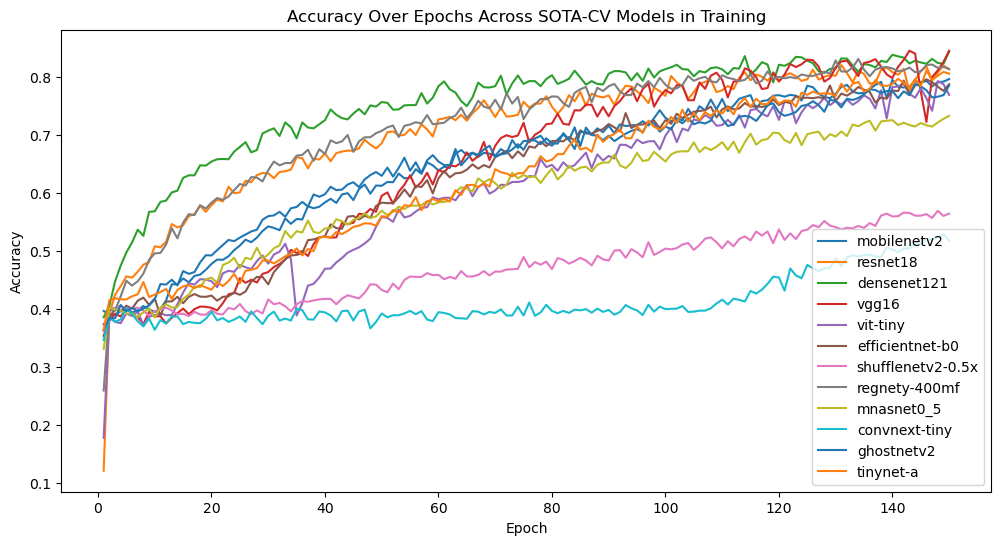

Average & Highest Training Precision for mobilenetv2: 0.616873, 0.795273
Average & Highest Training Precision for resnet18: 0.693347, 0.821693
Average & Highest Training Precision for densenet121: 0.739659, 0.843718
Average & Highest Training Precision for vgg16: 0.612260, 0.846508
Average & Highest Training Precision for vit-tiny: 0.567479, 0.790608
Average & Highest Training Precision for efficientnet-b0: 0.593425, 0.791046
Average & Highest Training Precision for shufflenetv2-0.5x: 0.381570, 0.527311
Average & Highest Training Precision for regnety-400mf: 0.702147, 0.833455
Average & Highest Training Precision for mnasnet0_5: 0.552577, 0.723975
Average & Highest Training Precision for convnext-tiny: 0.322389, 0.452765
Average & Highest Training Precision for ghostnetv2: 0.611214, 0.783440
Average & Highest Training Precision for tinynet-a: 0.581773, 0.809078


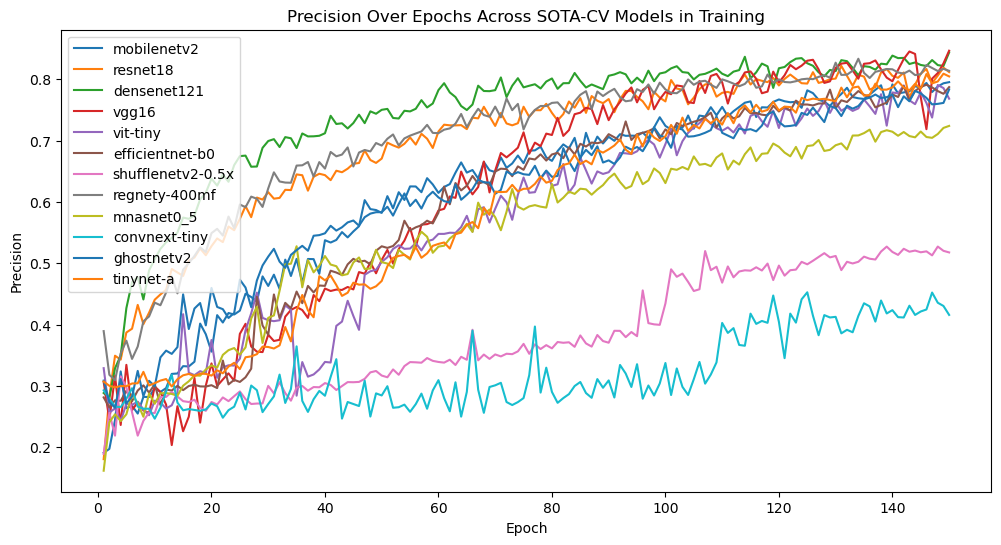

Average & Highest Training Recall for mobilenetv2: 0.650657, 0.796655
Average & Highest Training Recall for resnet18: 0.708460, 0.820863
Average & Highest Training Recall for densenet121: 0.751678, 0.843750
Average & Highest Training Recall for vgg16: 0.651969, 0.845511
Average & Highest Training Recall for vit-tiny: 0.606634, 0.793134
Average & Highest Training Recall for efficientnet-b0: 0.630663, 0.796215
Average & Highest Training Recall for shufflenetv2-0.5x: 0.471649, 0.569542
Average & Highest Training Recall for regnety-400mf: 0.715593, 0.831426
Average & Highest Training Recall for mnasnet0_5: 0.599413, 0.733275
Average & Highest Training Recall for convnext-tiny: 0.413225, 0.529489
Average & Highest Training Recall for ghostnetv2: 0.648938, 0.787852
Average & Highest Training Recall for tinynet-a: 0.627412, 0.811620


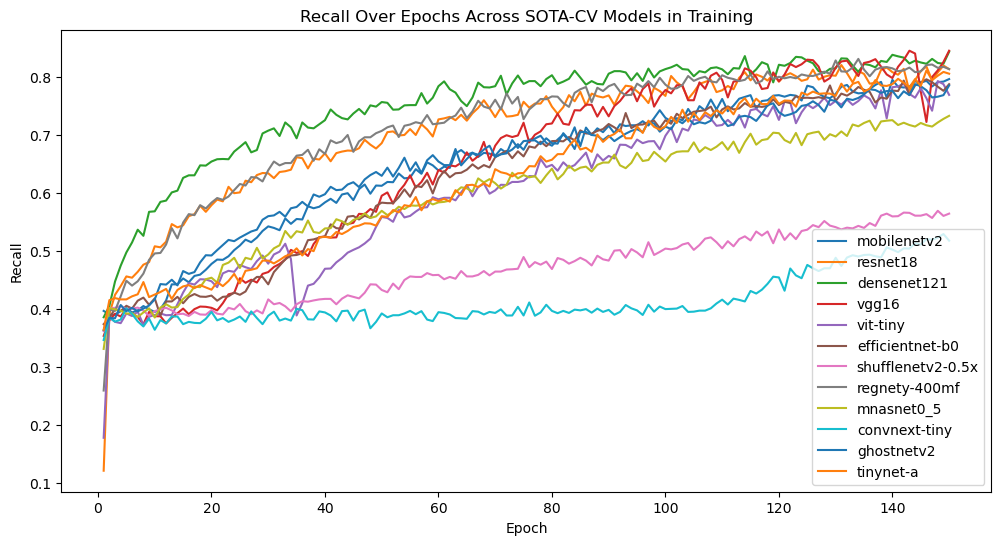

Average & Highest Training Auc for mobilenetv2: 0.819603, 0.945076
Average & Highest Training Auc for resnet18: 0.877816, 0.952107
Average & Highest Training Auc for densenet121: 0.906748, 0.962904
Average & Highest Training Auc for vgg16: 0.797520, 0.960582
Average & Highest Training Auc for vit-tiny: 0.774092, 0.937166
Average & Highest Training Auc for efficientnet-b0: 0.798065, 0.938575
Average & Highest Training Auc for shufflenetv2-0.5x: 0.631619, 0.763313
Average & Highest Training Auc for regnety-400mf: 0.878958, 0.955722
Average & Highest Training Auc for mnasnet0_5: 0.779108, 0.905895
Average & Highest Training Auc for convnext-tiny: 0.557847, 0.739948
Average & Highest Training Auc for ghostnetv2: 0.814006, 0.930229
Average & Highest Training Auc for tinynet-a: 0.793745, 0.947893


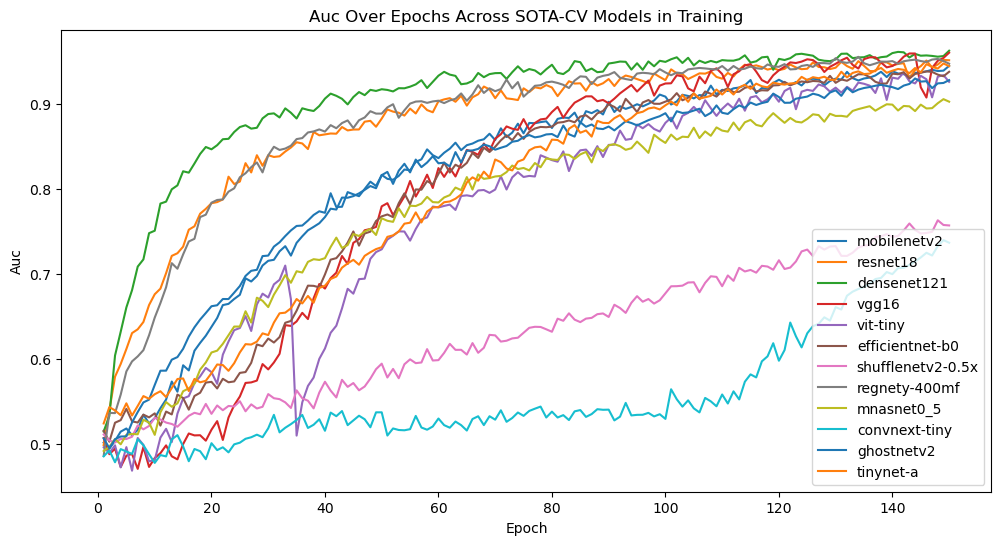

In [34]:
lineplot(linear_metrics, models, dfs_all_training, "training")

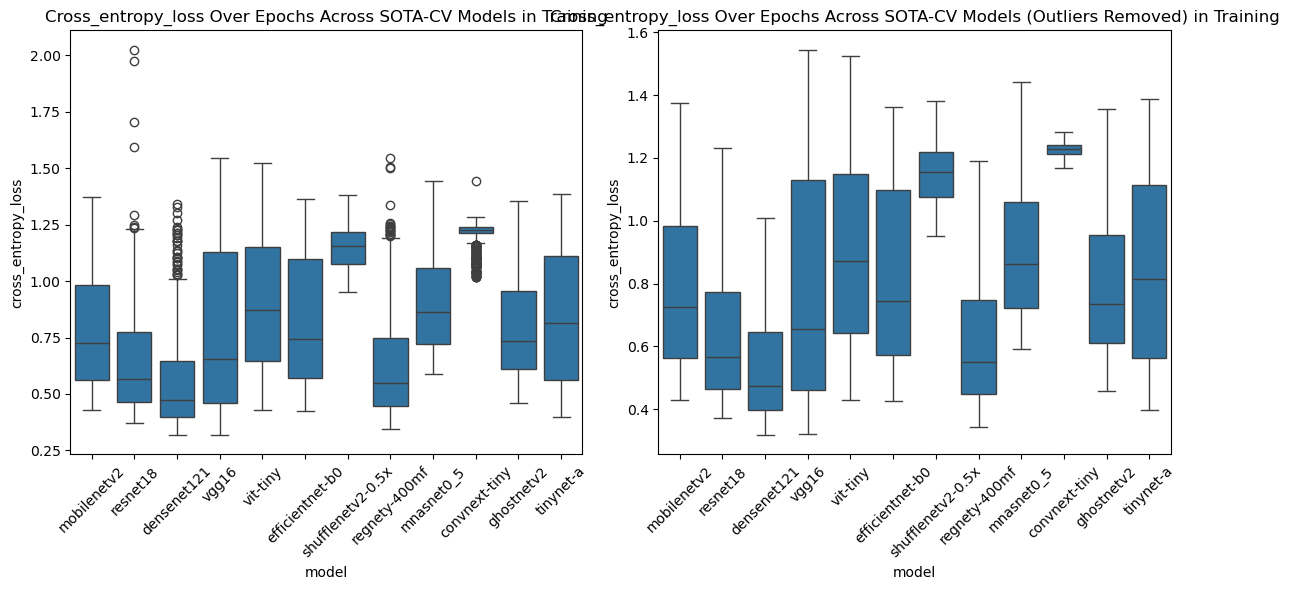

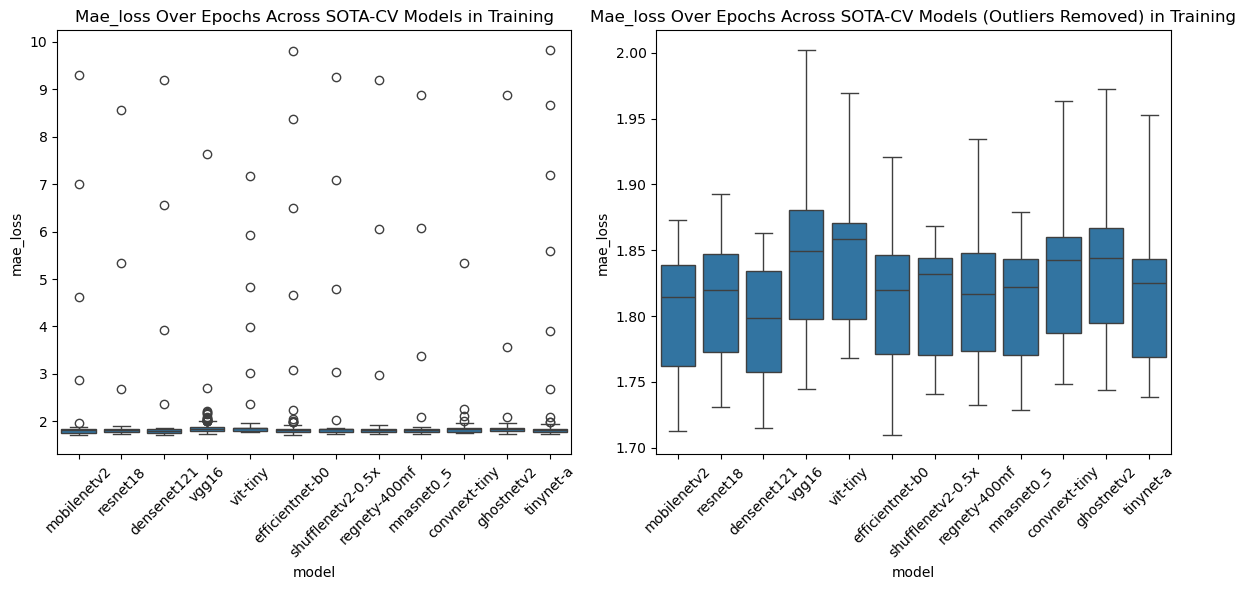

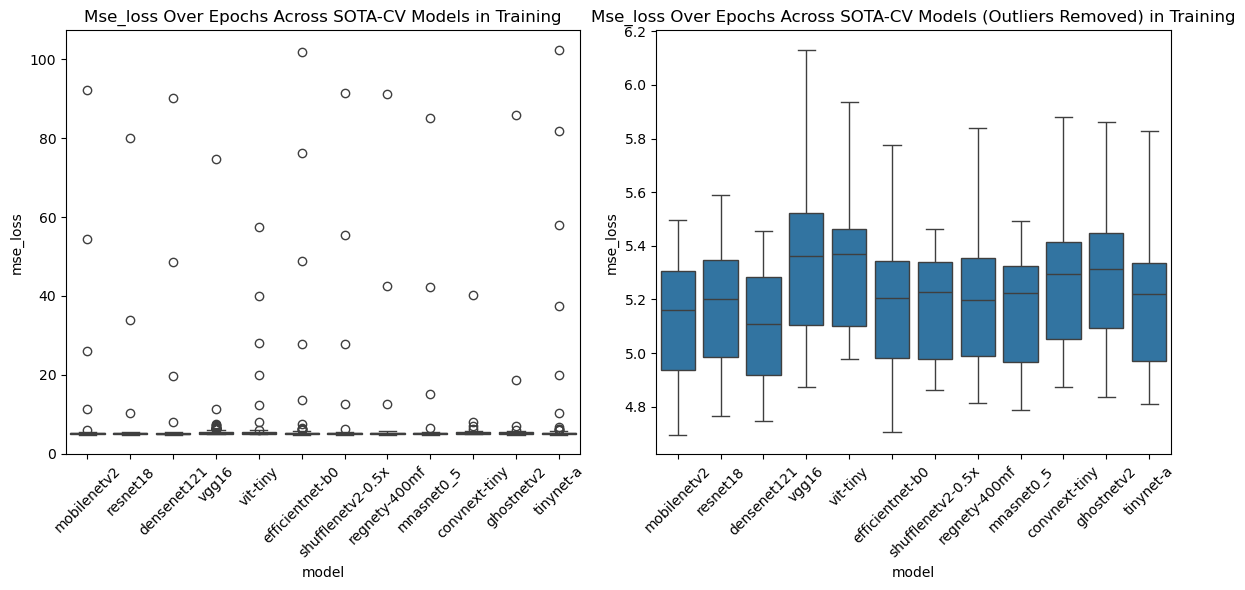

In [35]:
boxplot(boxplot_metrics, models, dfs_all_training, "training")

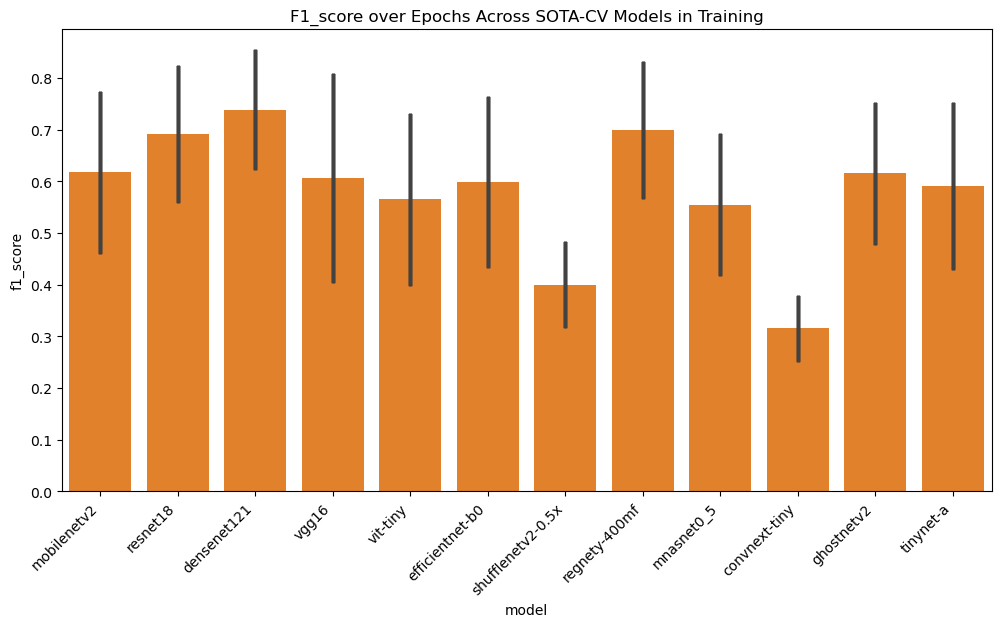

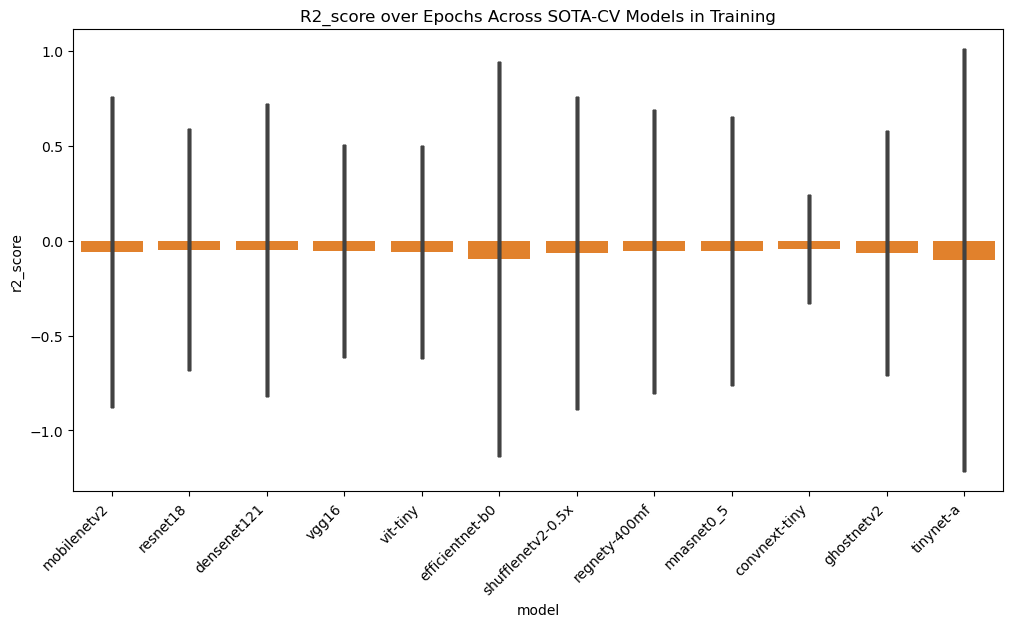

In [36]:
barplot(barplot_metrics, models, dfs_all_training, "training")

Average & Highest Validation Accuracy for mobilenetv2: 0.649202, 0.838028
Average & Highest Validation Accuracy for resnet18: 0.728310, 0.866197
Average & Highest Validation Accuracy for densenet121: 0.786808, 0.873239
Average & Highest Validation Accuracy for vgg16: 0.661127, 0.866197
Average & Highest Validation Accuracy for vit-tiny: 0.622676, 0.830986
Average & Highest Validation Accuracy for efficientnet-b0: 0.671174, 0.859155
Average & Highest Validation Accuracy for shufflenetv2-0.5x: 0.488920, 0.619718
Average & Highest Validation Accuracy for regnety-400mf: 0.739531, 0.859155
Average & Highest Validation Accuracy for mnasnet0_5: 0.385775, 0.387324
Average & Highest Validation Accuracy for convnext-tiny: 0.410329, 0.563380
Average & Highest Validation Accuracy for ghostnetv2: 0.675681, 0.830986
Average & Highest Validation Accuracy for tinynet-a: 0.672629, 0.887324


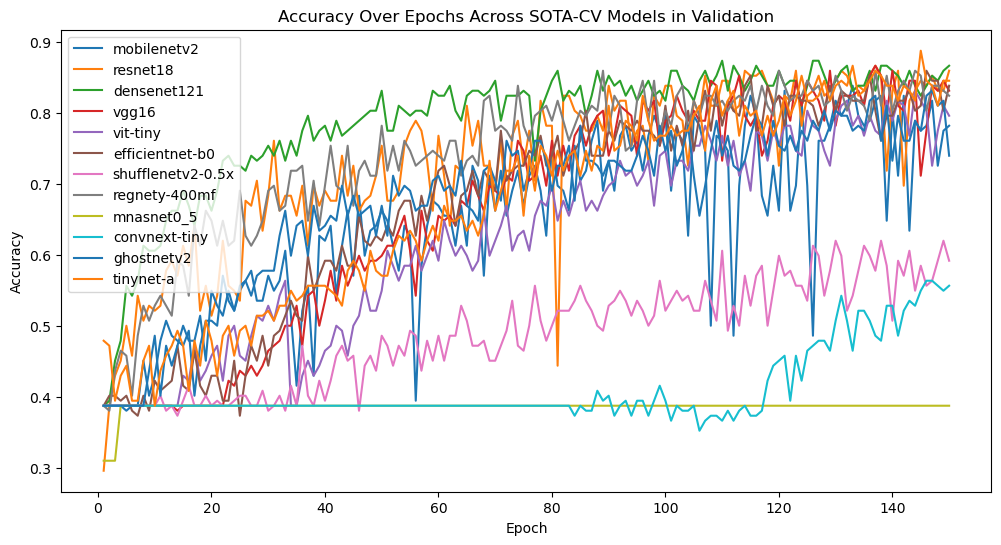

Average & Highest Validation Precision for mobilenetv2: 0.639199, 0.845565
Average & Highest Validation Precision for resnet18: 0.729004, 0.873187
Average & Highest Validation Precision for densenet121: 0.785146, 0.885259
Average & Highest Validation Precision for vgg16: 0.614064, 0.870601
Average & Highest Validation Precision for vit-tiny: 0.565461, 0.835550
Average & Highest Validation Precision for efficientnet-b0: 0.637006, 0.862878
Average & Highest Validation Precision for shufflenetv2-0.5x: 0.392742, 0.699237
Average & Highest Validation Precision for regnety-400mf: 0.728673, 0.870799
Average & Highest Validation Precision for mnasnet0_5: 0.148940, 0.150020
Average & Highest Validation Precision for convnext-tiny: 0.229286, 0.589087
Average & Highest Validation Precision for ghostnetv2: 0.634403, 0.835546
Average & Highest Validation Precision for tinynet-a: 0.629157, 0.879707


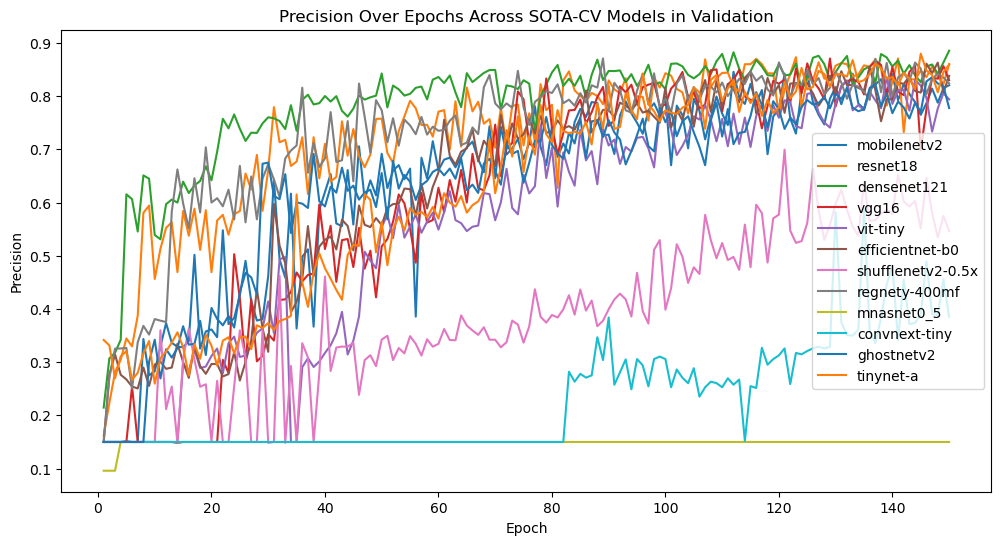

Average & Highest Validation Recall for mobilenetv2: 0.649202, 0.838028
Average & Highest Validation Recall for resnet18: 0.728310, 0.866197
Average & Highest Validation Recall for densenet121: 0.786808, 0.873239
Average & Highest Validation Recall for vgg16: 0.661127, 0.866197
Average & Highest Validation Recall for vit-tiny: 0.622676, 0.830986
Average & Highest Validation Recall for efficientnet-b0: 0.671174, 0.859155
Average & Highest Validation Recall for shufflenetv2-0.5x: 0.488920, 0.619718
Average & Highest Validation Recall for regnety-400mf: 0.739531, 0.859155
Average & Highest Validation Recall for mnasnet0_5: 0.385775, 0.387324
Average & Highest Validation Recall for convnext-tiny: 0.410329, 0.563380
Average & Highest Validation Recall for ghostnetv2: 0.675681, 0.830986
Average & Highest Validation Recall for tinynet-a: 0.672629, 0.887324


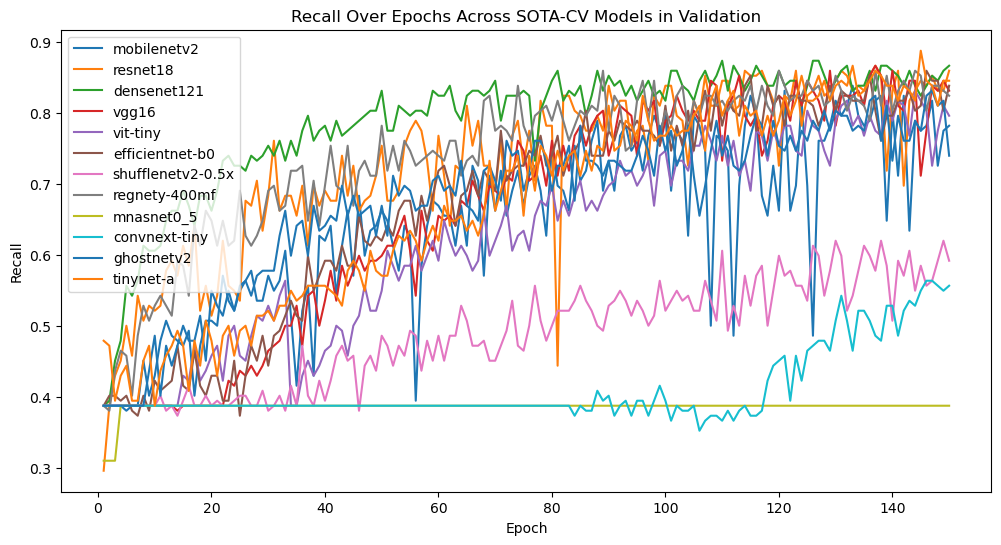

Average & Highest Validation Auc for mobilenetv2: 0.841407, 0.955137
Average & Highest Validation Auc for resnet18: 0.895115, 0.969667
Average & Highest Validation Auc for densenet121: 0.925817, 0.976820
Average & Highest Validation Auc for vgg16: 0.816324, 0.966928
Average & Highest Validation Auc for vit-tiny: 0.809887, 0.944138
Average & Highest Validation Auc for efficientnet-b0: 0.832219, 0.966450
Average & Highest Validation Auc for shufflenetv2-0.5x: 0.683218, 0.818602
Average & Highest Validation Auc for regnety-400mf: 0.893688, 0.964390
Average & Highest Validation Auc for mnasnet0_5: 0.463603, 0.615257
Average & Highest Validation Auc for convnext-tiny: 0.583833, 0.768068
Average & Highest Validation Auc for ghostnetv2: 0.837899, 0.955626
Average & Highest Validation Auc for tinynet-a: 0.831445, 0.971039


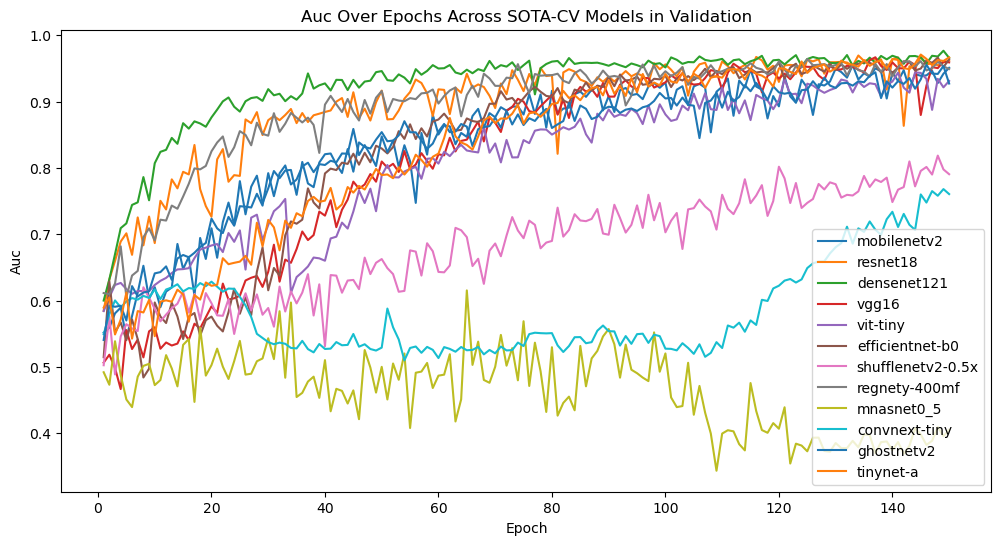

In [37]:
lineplot(linear_metrics, models, dfs_all_validation, "validation")

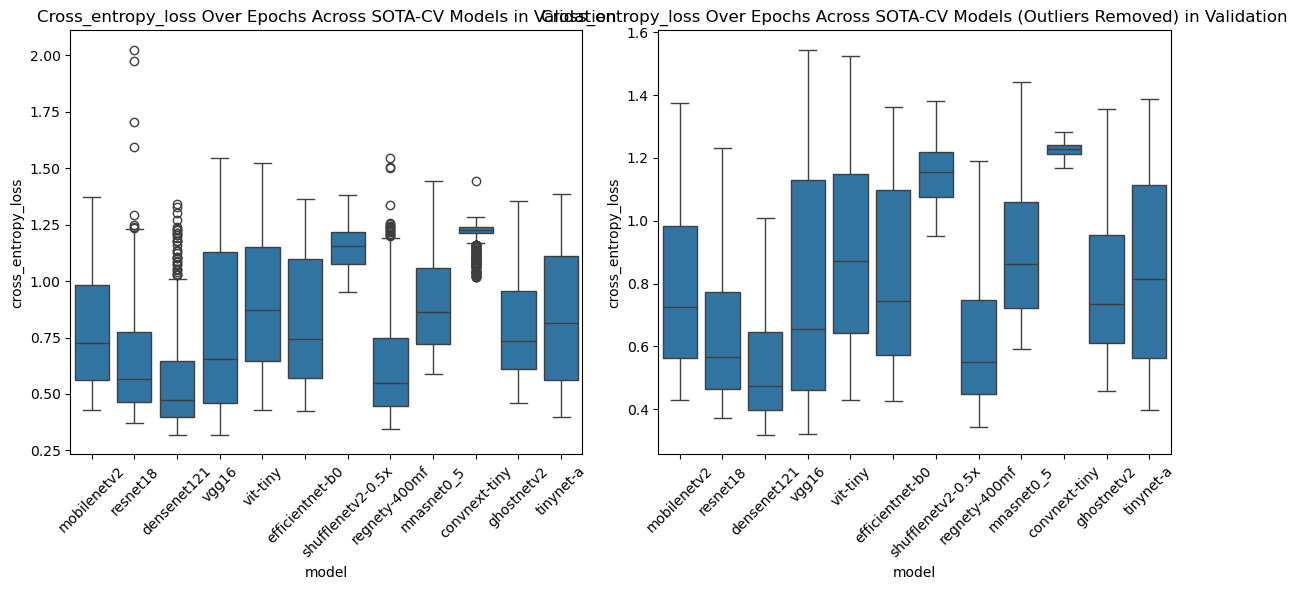

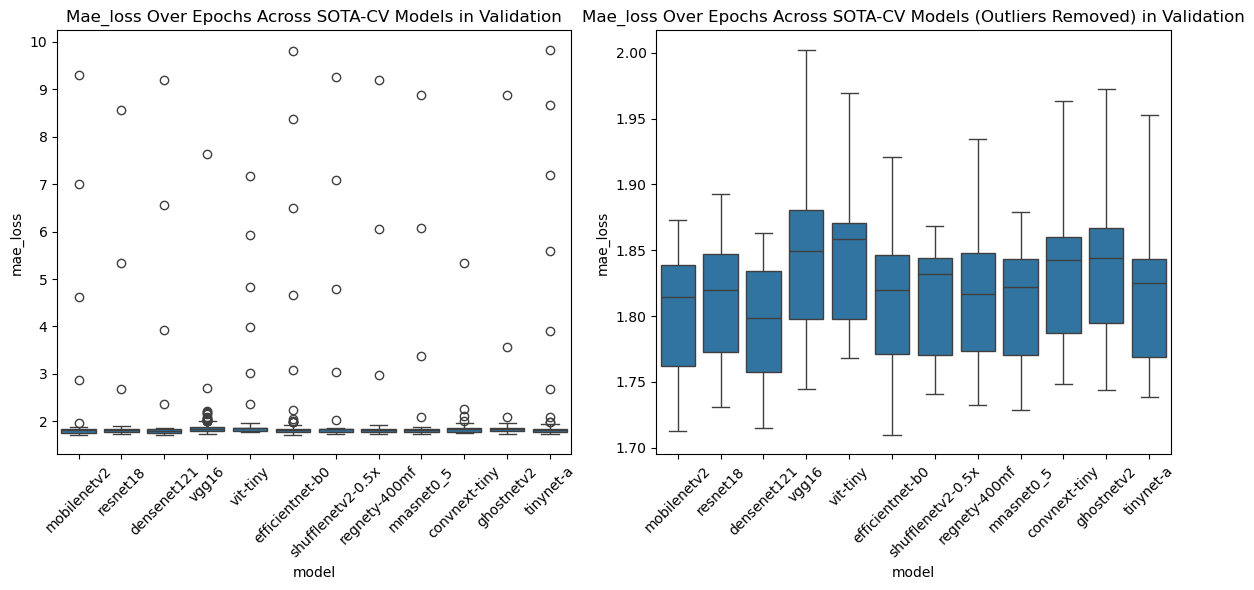

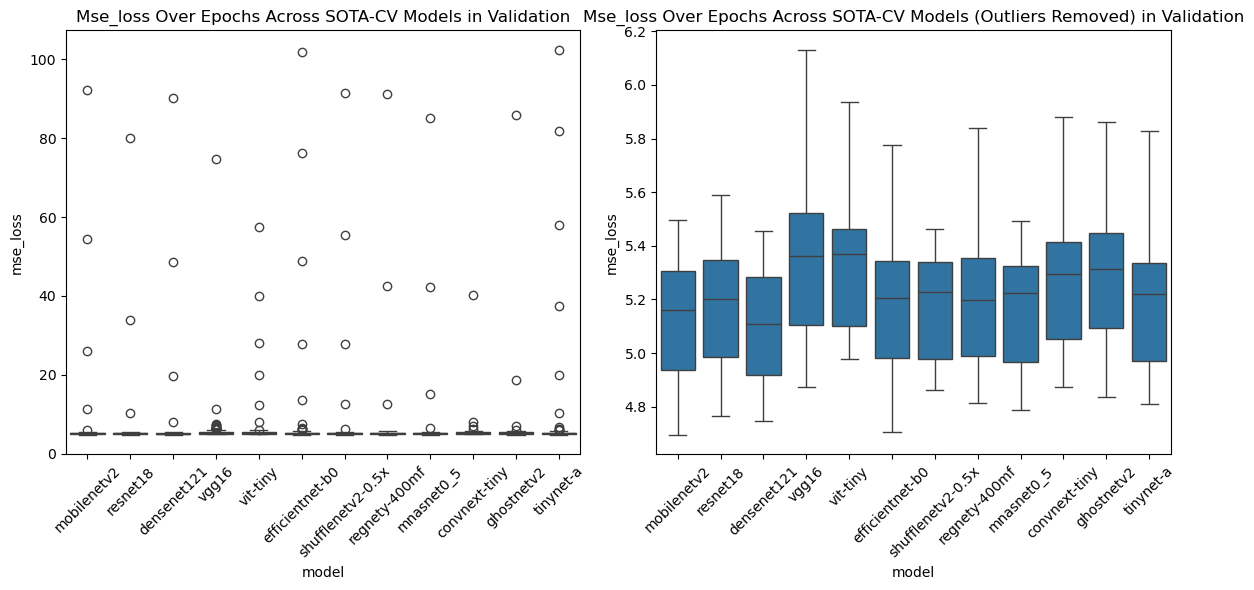

In [38]:
boxplot(boxplot_metrics, models, dfs_all_training, "validation")

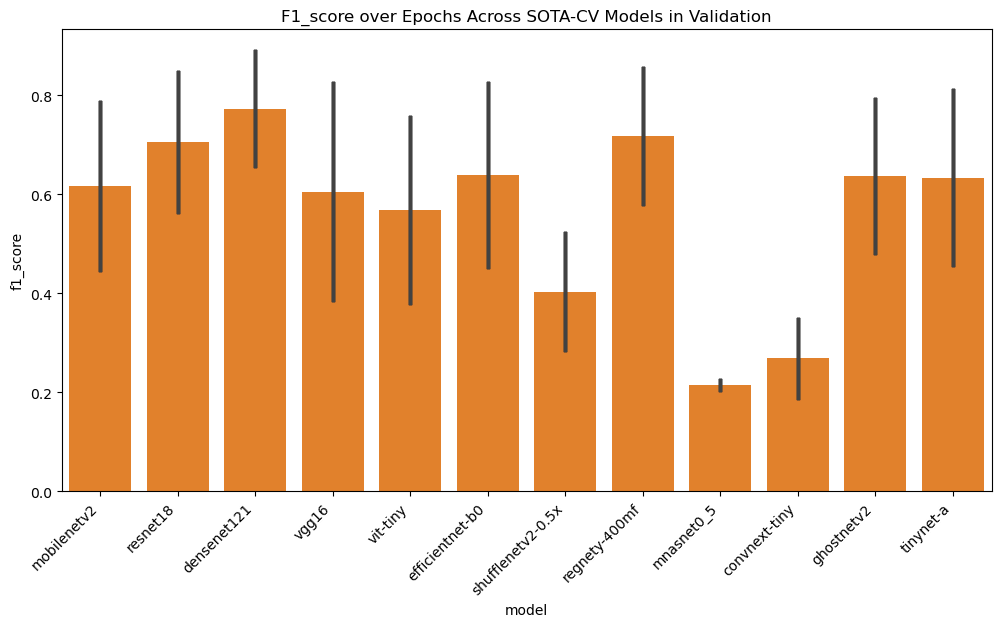

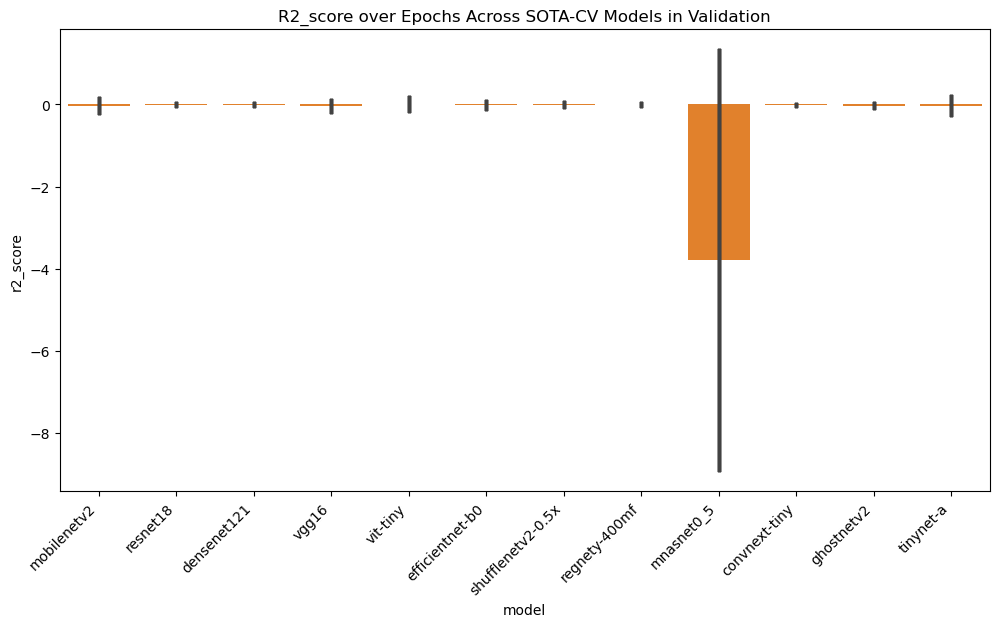

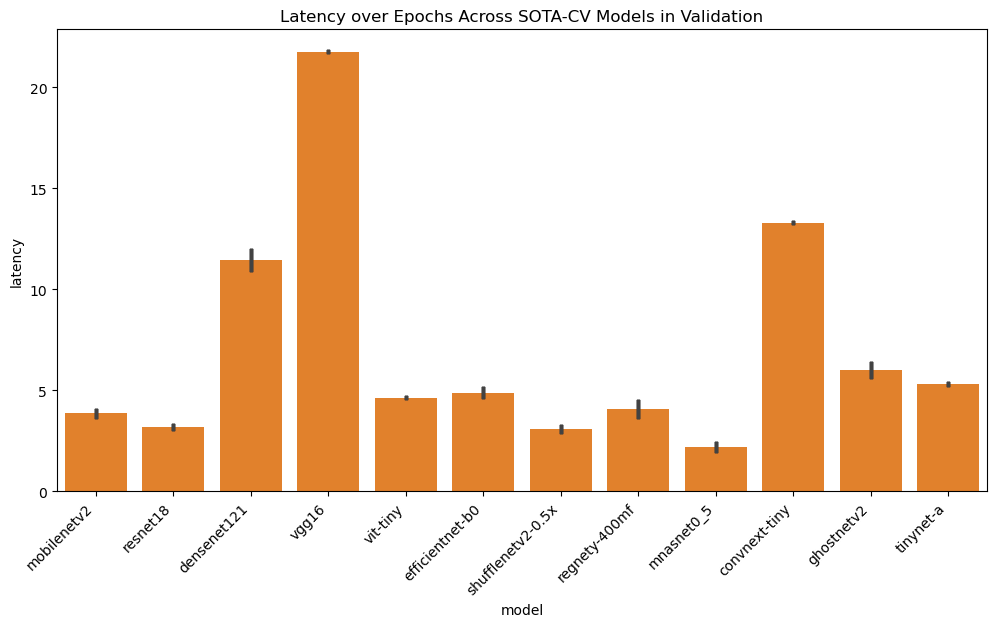

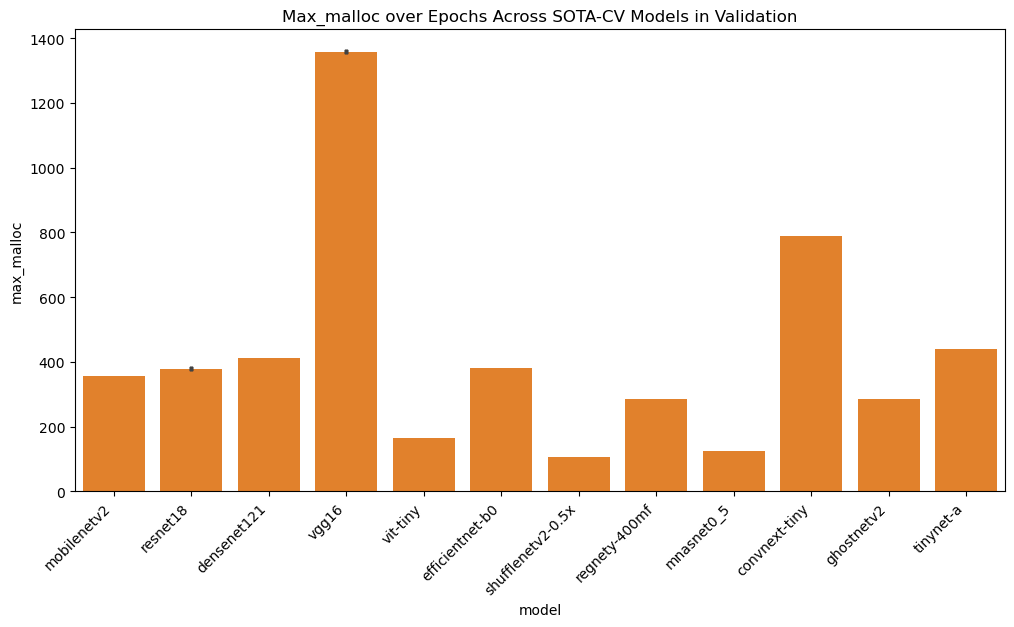

In [39]:
barplot(barplot_metrics, models, dfs_all_validation, "validation")

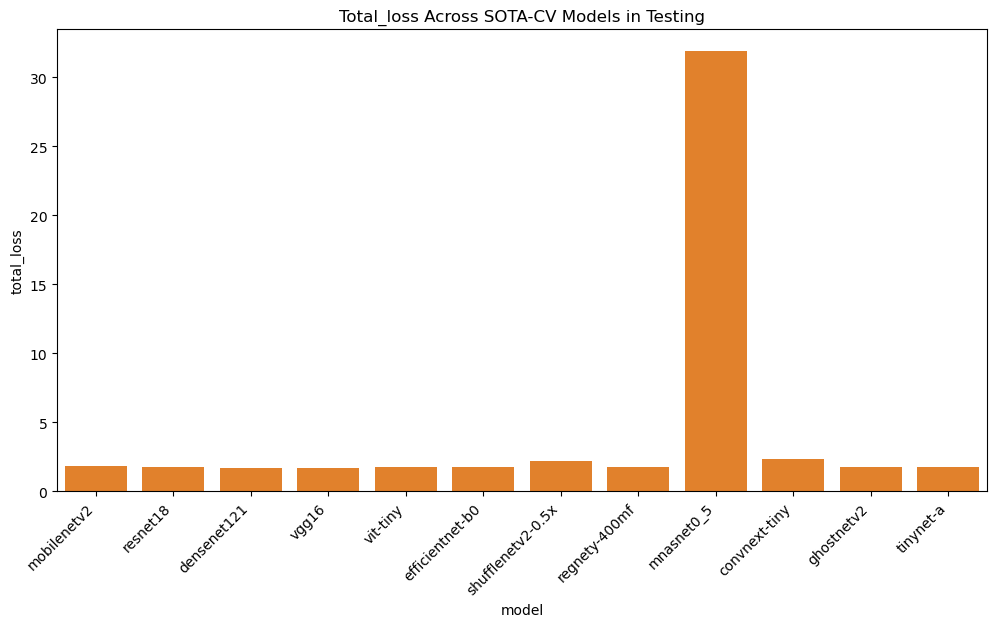

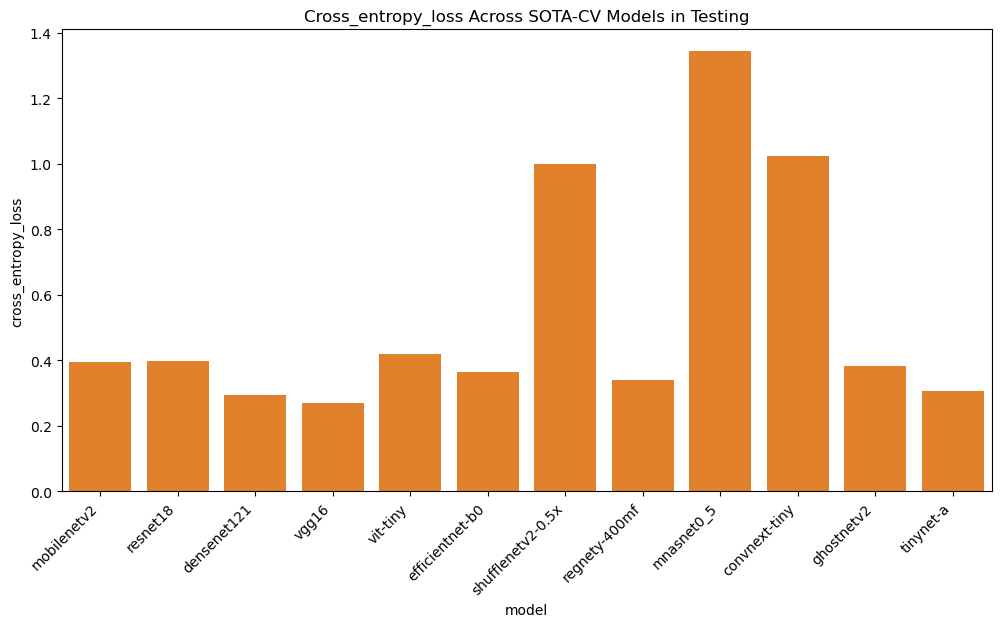

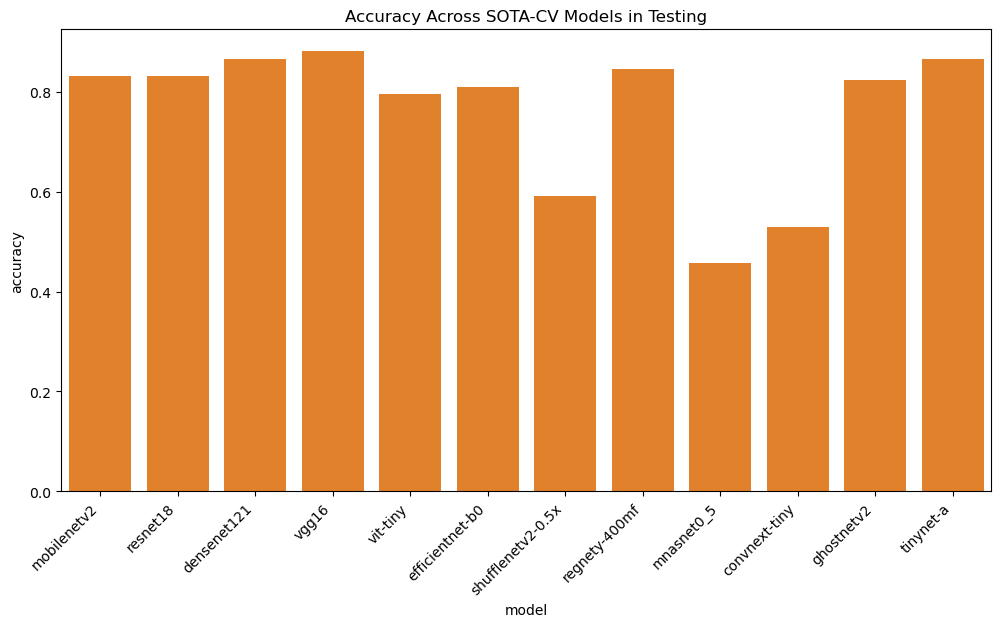

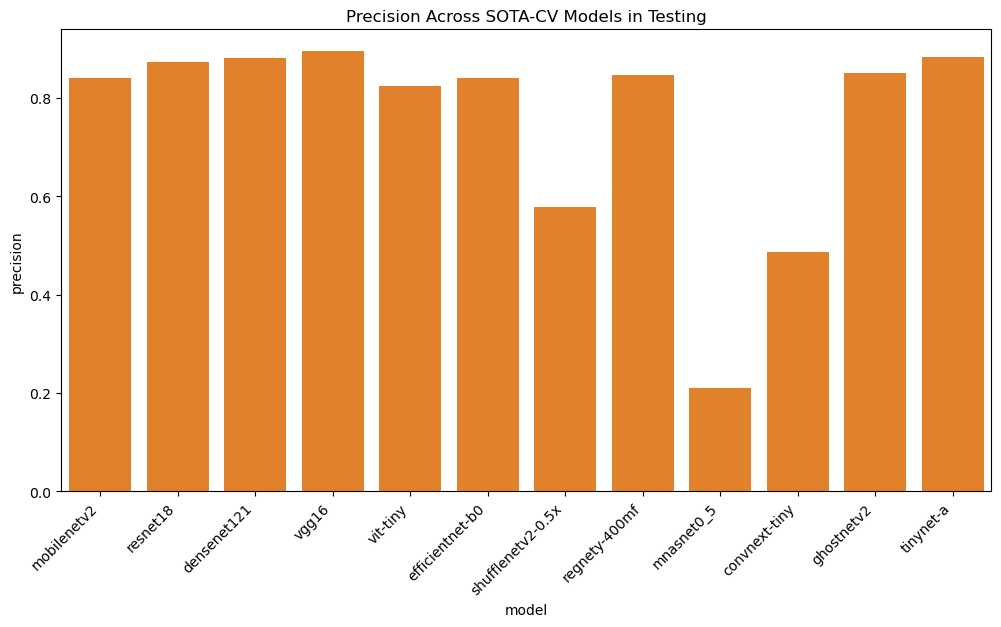

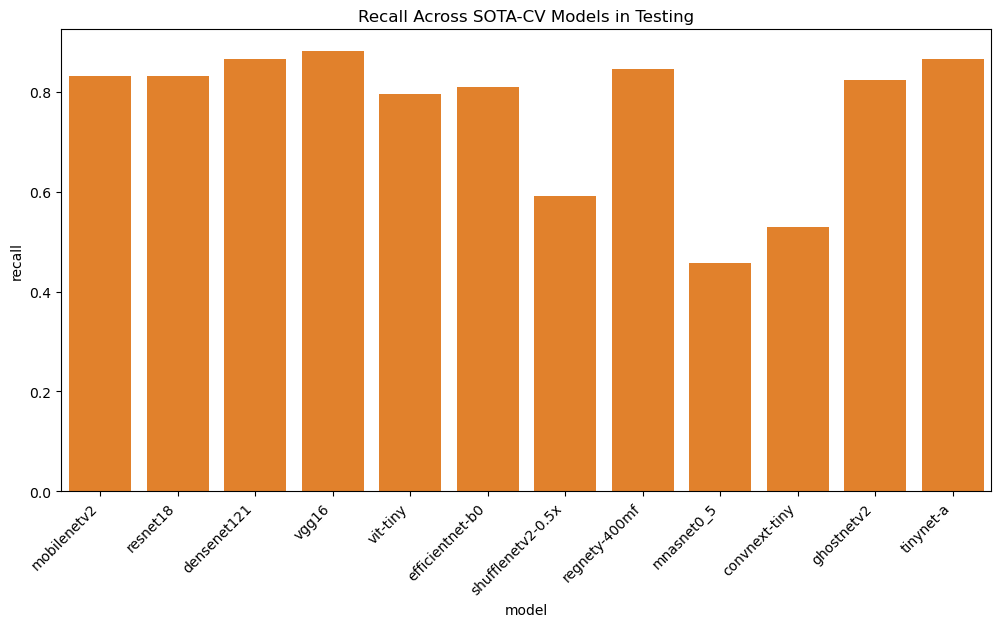

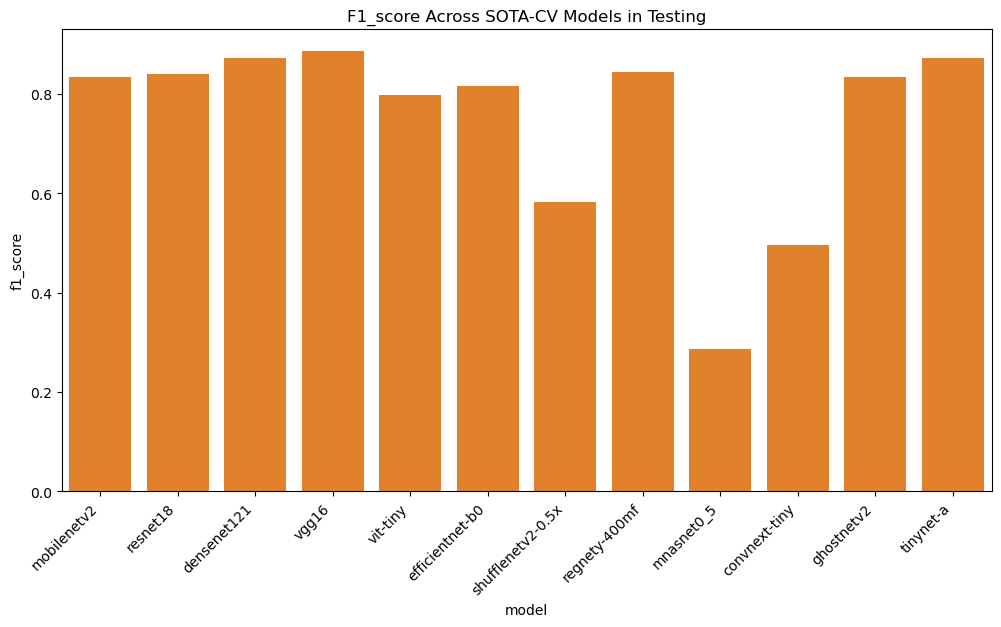

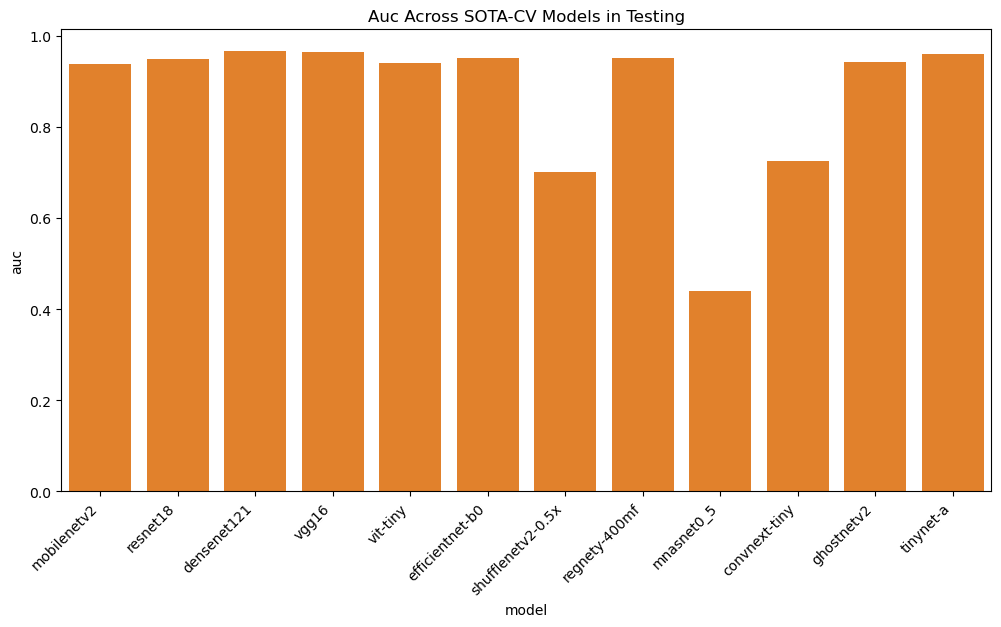

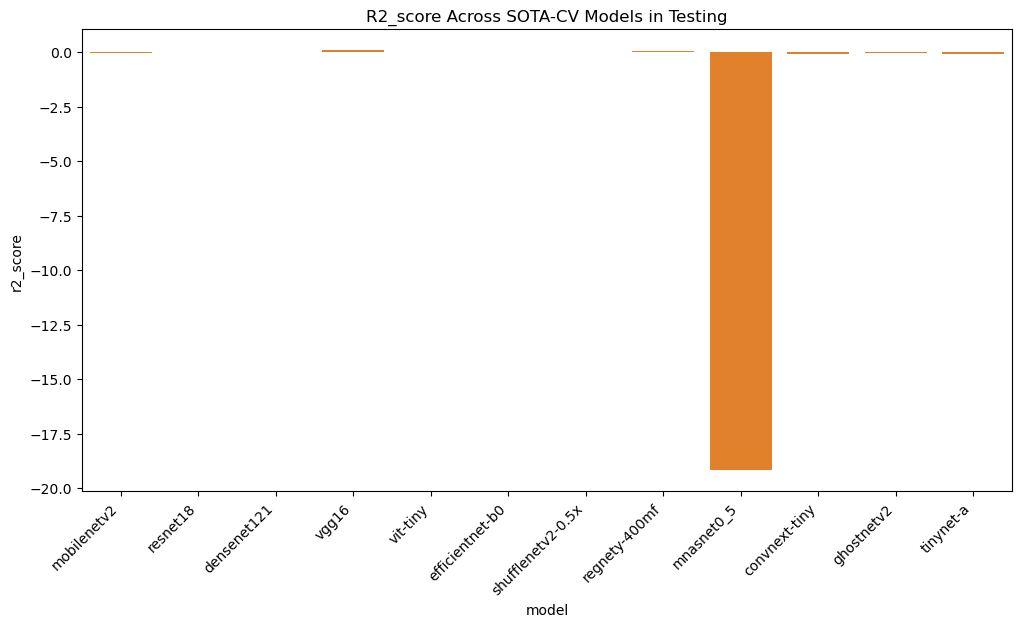

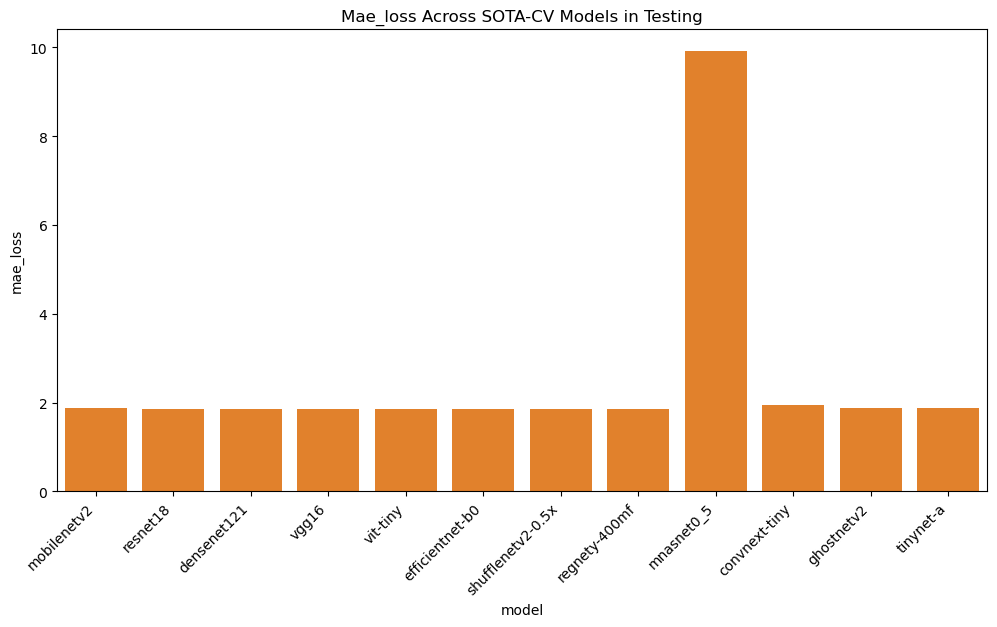

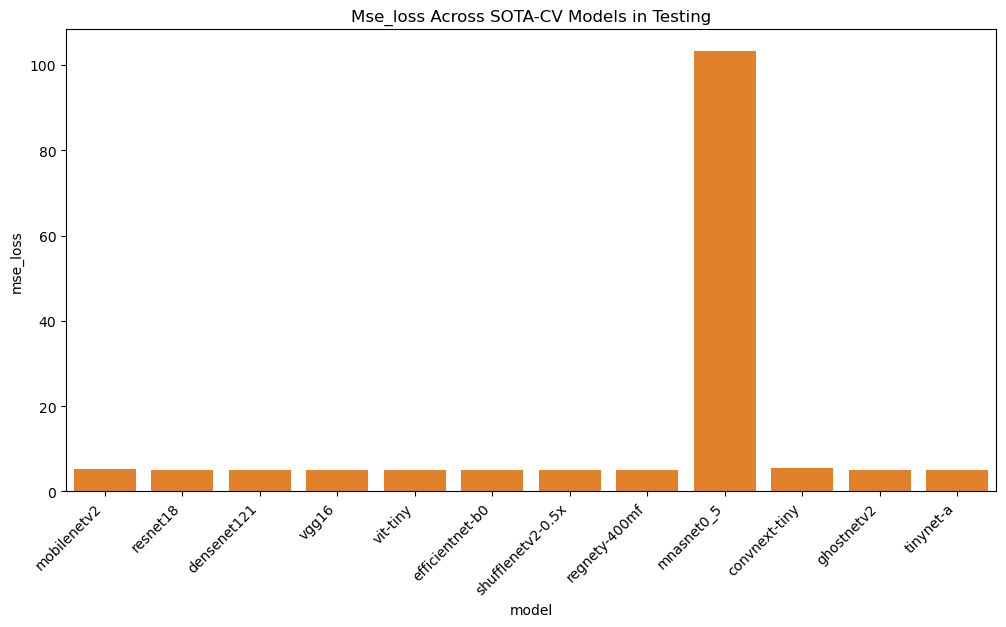

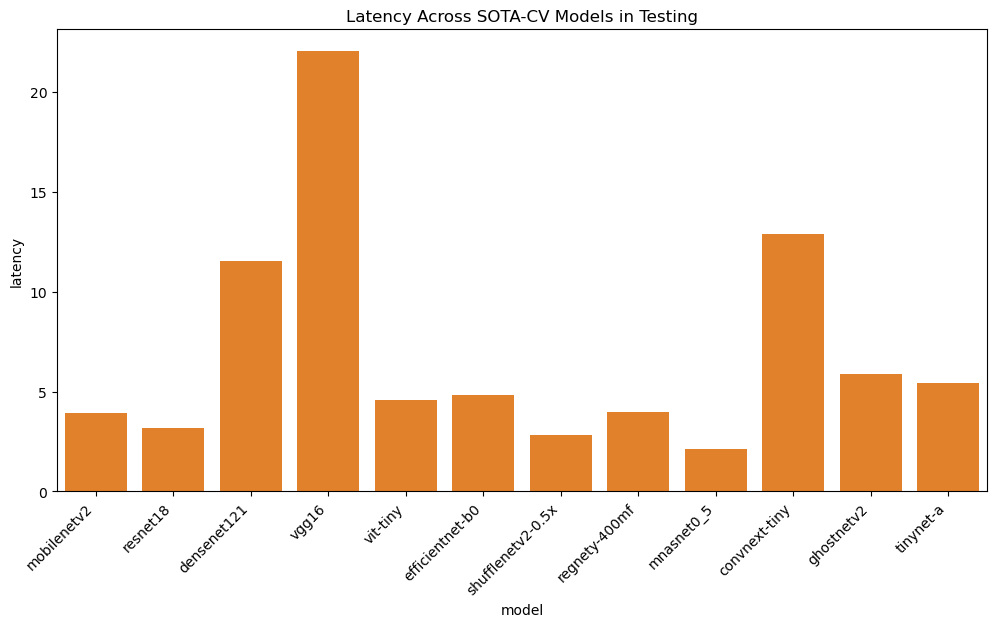

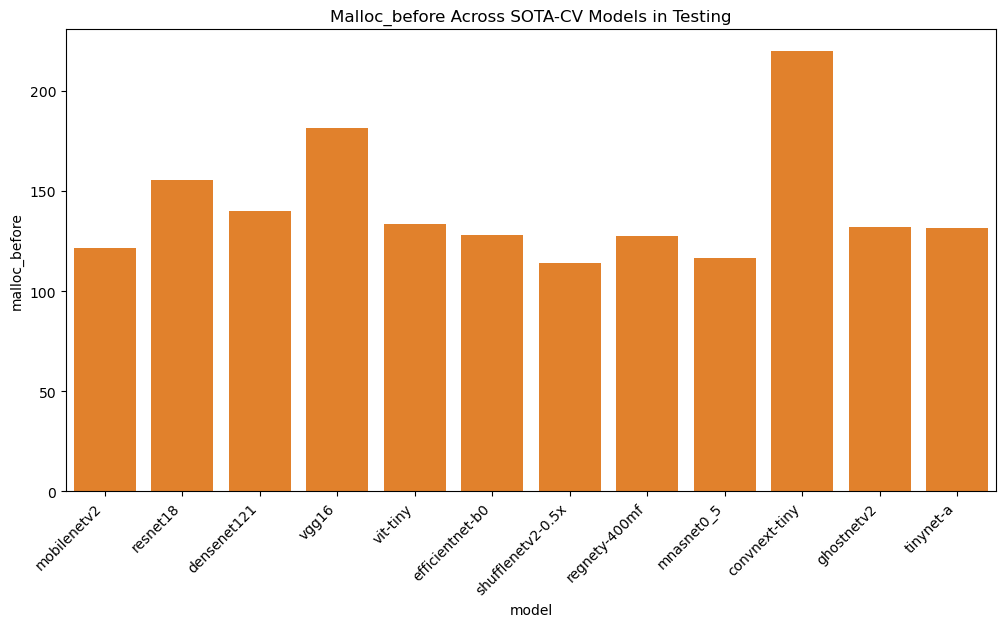

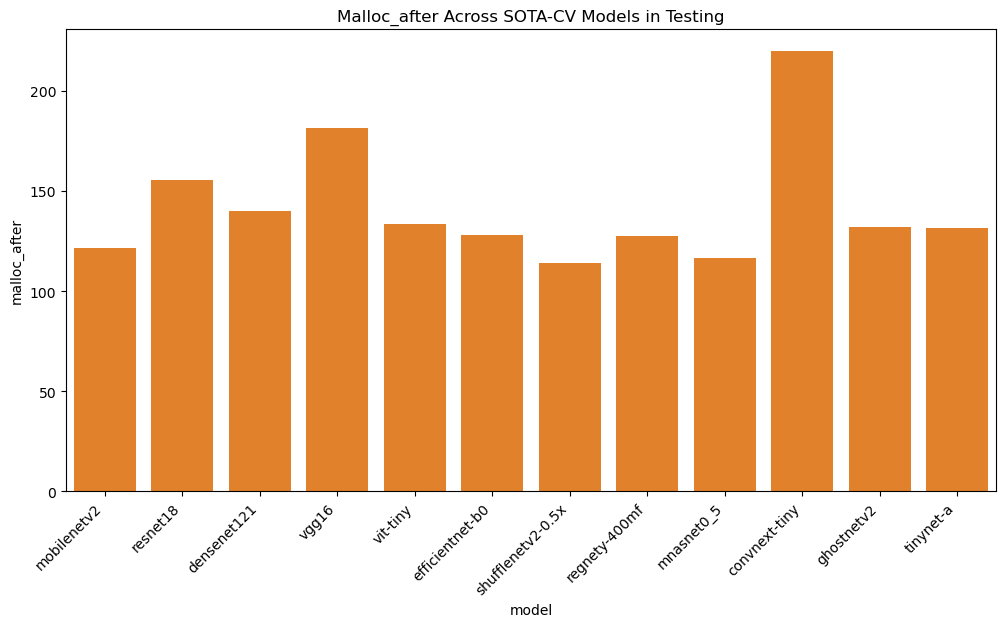

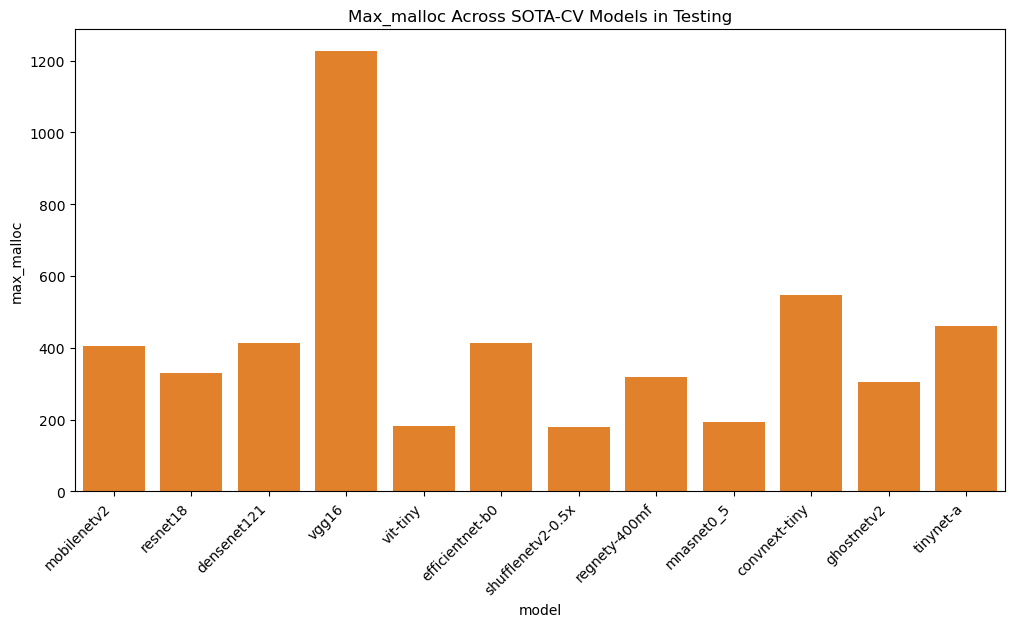

In [40]:
df = dfs_all_testing
mode = "testing"
for metric in dfs_all_testing.columns[:-1]:
        plt.figure(figsize=(12, 6))
        for model in models:
            # Plot the metric
            sns.barplot(x="model", y=metric, data=df, errorbar="sd")
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{metric.capitalize()} Across SOTA-CV Models in {mode.capitalize()}")
        plt.show()

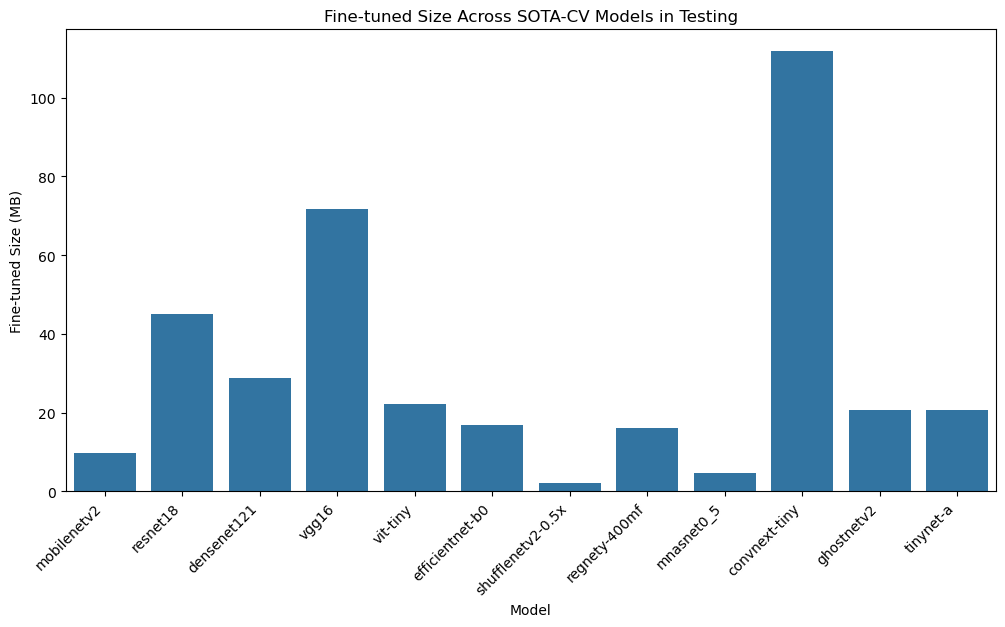

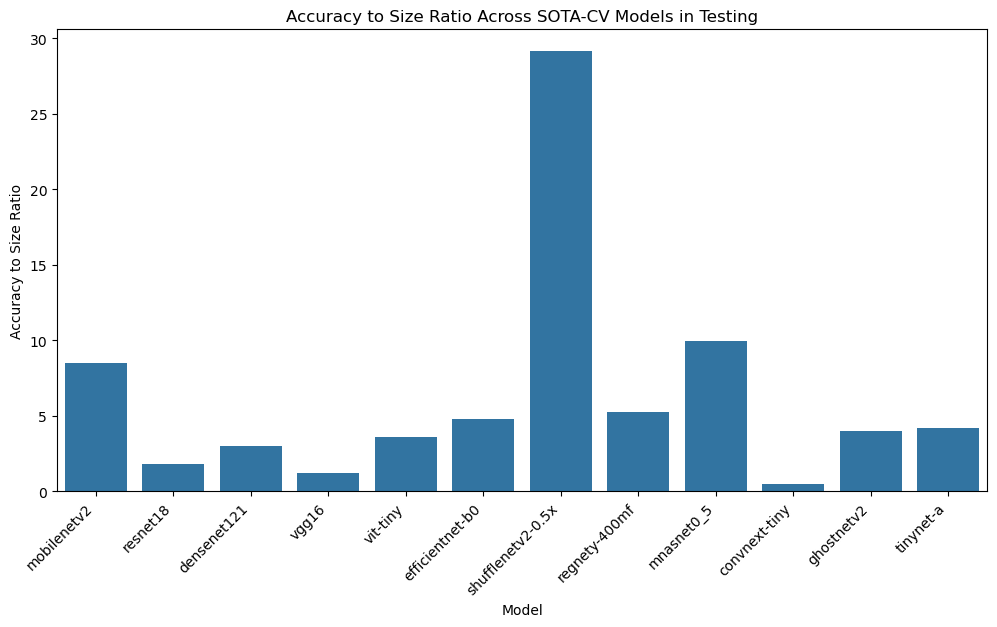

In [42]:
fine_tuned_size = {
    "mobilenetv2": 9.79,
    "resnet18": 45.05, 
    "densenet121": 28.91, 
    "vgg16": 71.72, 
    "vit-tiny": 22.25,
    "efficientnet-b0": 16.97, 
    "shufflenetv2-0.5x": 2.03, 
    "regnety-400mf": 16.08,
    "mnasnet0_5": 4.59, 
    "convnext-tiny": 111.73, 
    "ghostnetv2": 20.66, 
    "tinynet-a": 20.63
}

df_finetuned_size = pd.DataFrame(list(fine_tuned_size.items()), columns=["Model", "Fine-tuned Size (MB)"])

df_finetuned_size["Accuracy"] = dfs_all_testing["accuracy"]

for i, row in df_finetuned_size.iterrows():
    ratio = row["Accuracy"]/row["Fine-tuned Size (MB)"]*100

    df_finetuned_size.loc[i, "Accuracy to Size Ratio"] = ratio
df_finetuned_size

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Fine-tuned Size (MB)", data=df_finetuned_size)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.title(f"Fine-tuned Size Across SOTA-CV Models in {mode.capitalize()}")

plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Accuracy to Size Ratio", data=df_finetuned_size)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.title(f"Accuracy to Size Ratio Across SOTA-CV Models in {mode.capitalize()}")

plt.show()

# Comparison of PTQ on Different Metrics Across Different Models

In [106]:
def load_metrics_csv(split, comp_method, mode):
    # to store all dfs from the csv files
    dfs = []

    models = ["mobilenetv2", "resnet18", "densenet121", "vgg16", "vit-tiny",
               "efficientnet-b0", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "convnext-tiny", "ghostnetv2", "tinynet-a"]

    precision = ["fp32","fp16","int8","int4"]

    # Load data from all CSVs
    for model in models:
        for bw in precision:
            # Load CSV in individual dataframe
            path = f"metrics/pytorch/{comp_method.lower()}/{split}_metrics_{model}_{comp_method.upper()}_{mode.upper()}.csv"
            csv_file = glob.glob(path)
            
            df = pd.read_csv(csv_file[0])

            
            # Append to the list of dataframes for all models
        dfs.append(df)

    # Concatenate all data into a single DataFrame
    dfs_all = pd.concat(dfs, ignore_index=True)
    
    return dfs_all

import re
def extract_float(s):
    match = re.search(r'\d+\.\d+', s)
    return float(match.group()) if match else None


In [107]:
dfs_infer_ptq = load_metrics_csv("testing", "quantization", "ptq")
dfs_infer_ptq['model_size'] = dfs_infer_ptq['model_size'].apply(extract_float)
dfs_infer_ptq['size_to_accuracy'] = dfs_infer_ptq['accuracy']/dfs_infer_ptq['model_size']*100
dfs_infer_ptq['latency_to_accuracy'] = dfs_infer_ptq['accuracy']/dfs_infer_ptq['latency']*100

dfs_infer_ptq

,model,bit-width,model_size,total_loss,cross_entropy_loss,accuracy,precision,recall,f1_score,auc,r2_score,mae_loss,mse_loss,latency,malloc_before,malloc_after,max_malloc,size_to_accuracy,latency_to_accuracy
0,mobilenetv2,fp32,9.78,2.107073,0.424507,0.795775,0.811268,0.795775,0.793520,0.0,-0.034820,1.975531,6.033060,213.731172,0.0,0.0,0.0,8.136755,0.372325
1,mobilenetv2,fp16,4.94,2.105078,0.422461,0.795775,0.811268,0.795775,0.793520,0.0,-0.034235,1.975195,6.030469,481.353802,0.0,0.0,0.0,16.108799,0.165320
2,mobilenetv2,int8,9.82,2.192289,0.541948,0.746479,0.800824,0.746479,0.758998,0.0,-0.009440,1.977666,6.043082,102.775842,0.0,0.0,0.0,7.601618,0.726317
3,mobilenetv2,int4,10.26,4.218861,3.448860,0.359155,0.375469,0.359155,0.366318,0.0,-0.022110,1.966796,6.015531,79.553208,0.0,0.0,0.0,3.500535,0.451465
4,resnet18,fp32,45.04,2.053102,0.410280,0.830986,0.832201,0.830986,0.826620,0.0,0.015064,1.934186,5.886355,50.497228,0.0,0.0,0.0,1.844995,1.645607
5,resnet18,fp16,22.54,2.052930,0.409912,0.830986,0.832201,0.830986,0.826620,0.0,0.014703,1.934180,5.886719,1517.653101,0.0,0.0,0.0,3.686717,0.054755
6,resnet18,int8,45.06,2.063323,0.424227,0.809859,0.813914,0.809859,0.810467,0.0,0.021732,1.934597,5.887881,65.256172,0.0,0.0,0.0,1.797291,1.241046
7,resnet18,int4,21.44,3.205383,2.003022,0.528169,0.620491,0.528169,0.439368,0.0,-0.094567,1.968360,6.010891,59.550927,0.0,0.0,0.0,2.463475,0.886920
8,densenet121,fp32,28.90,2.031694,0.372776,0.816901,0.818316,0.816901,0.816969,0.0,-0.009183,1.937412,5.902500,193.436826,0.0,0.0,0.0,2.826648,0.422309
9,densenet121,fp16,14.57,2.031055,0.372559,0.809859,0.810593,0.809859,0.809949,0.0,-0.009102,1.937305,5.900781,2354.546826,0.0,0.0,0.0,5.558402,0.034396


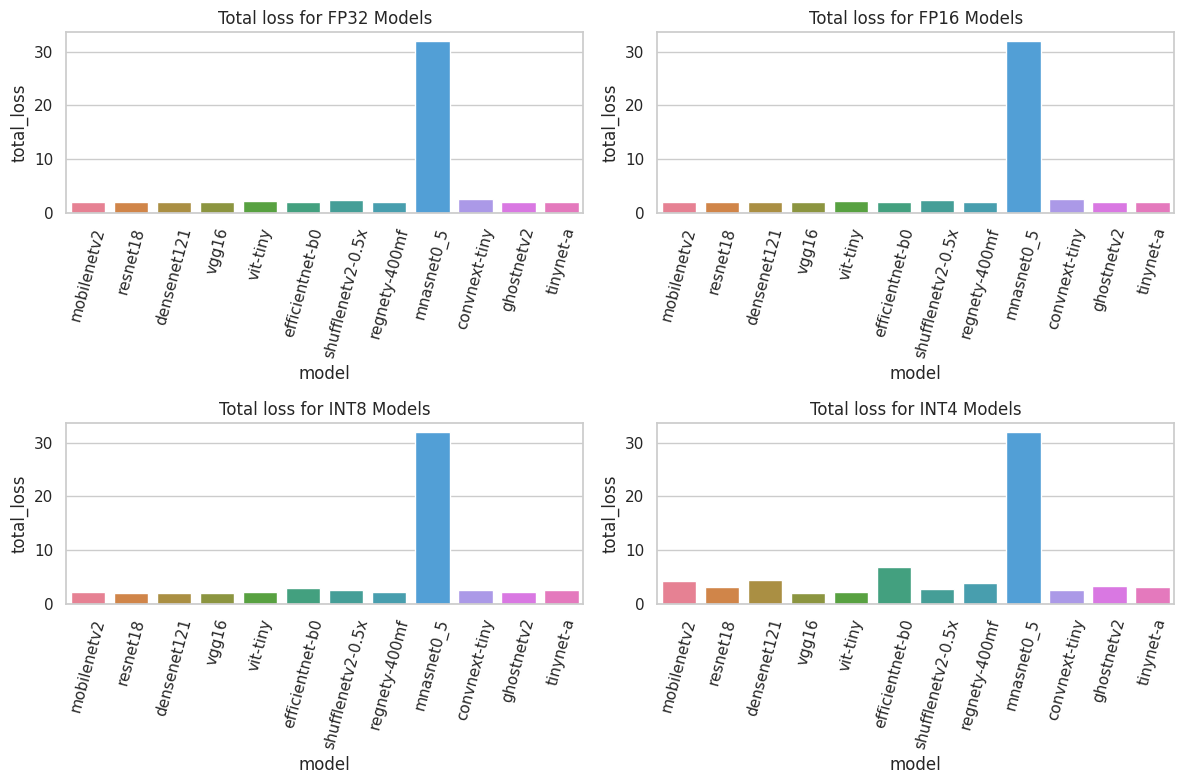

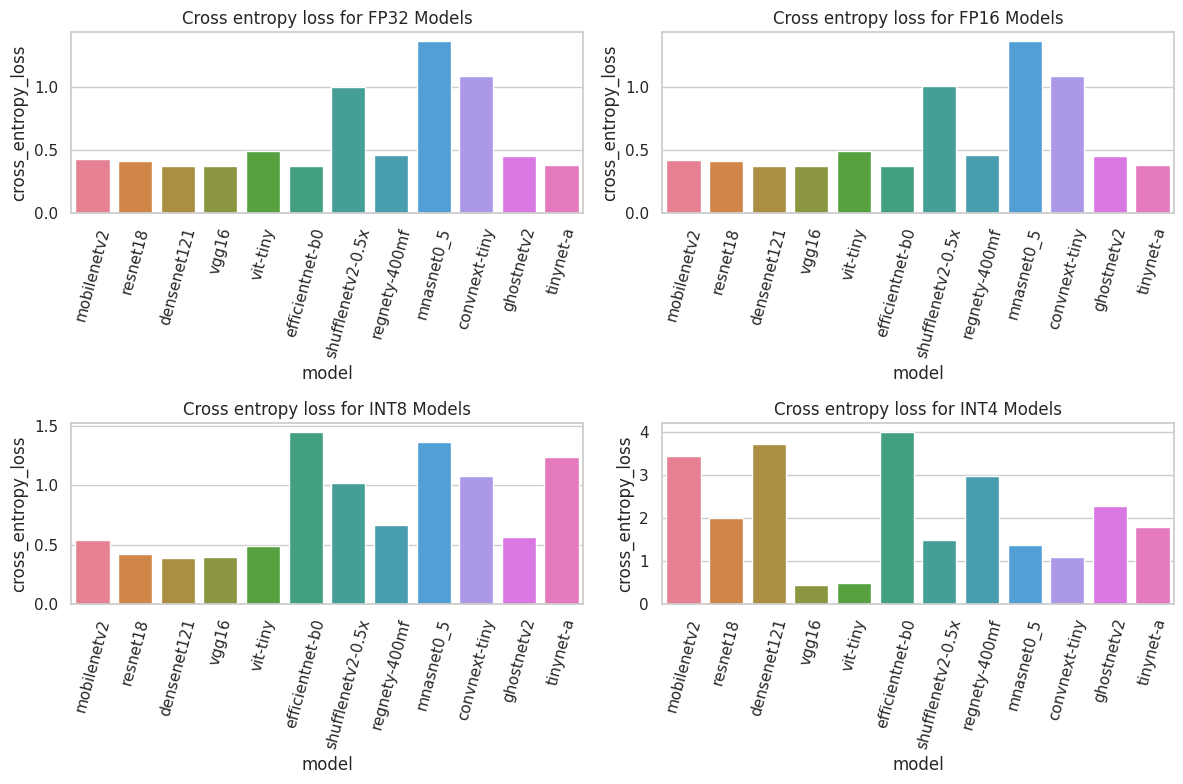

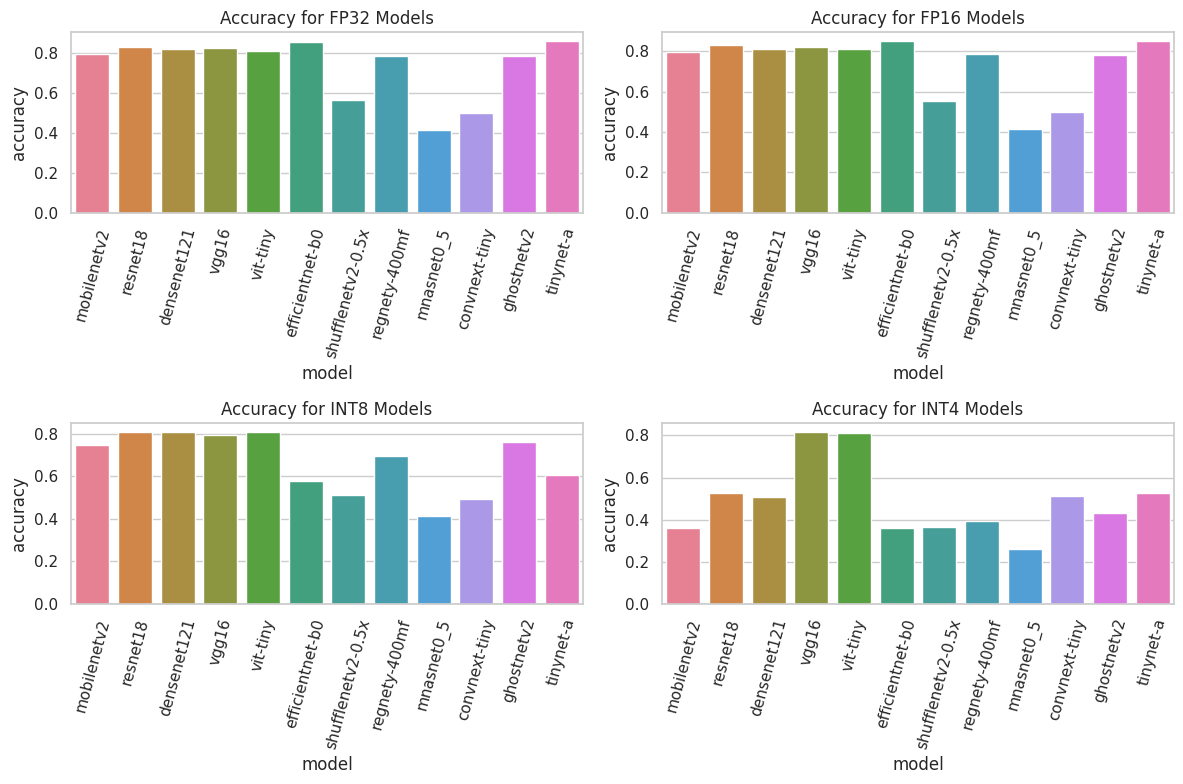

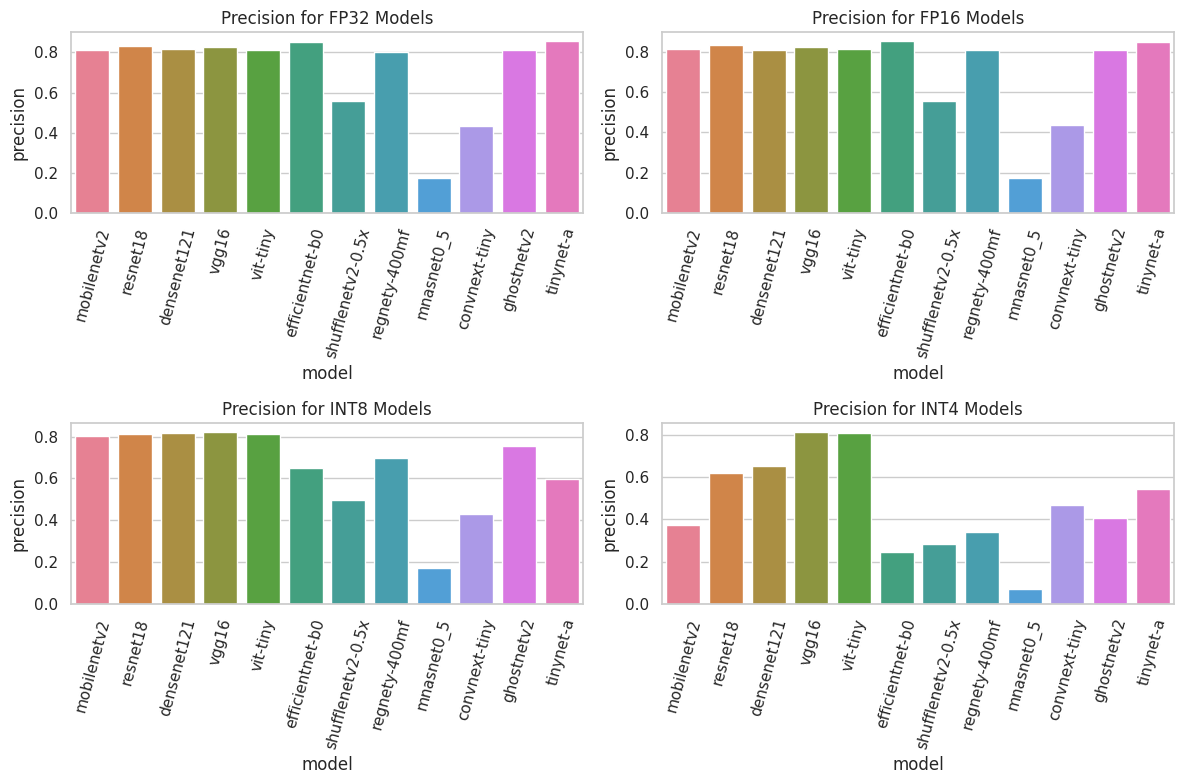

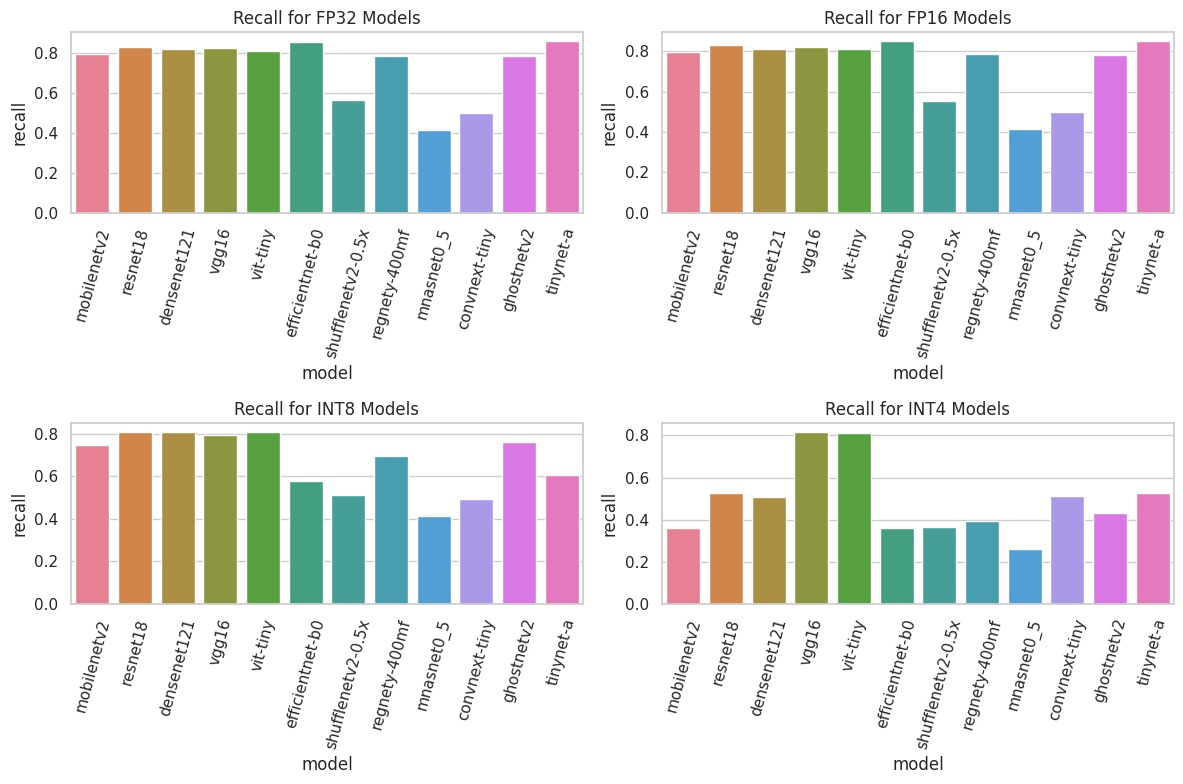

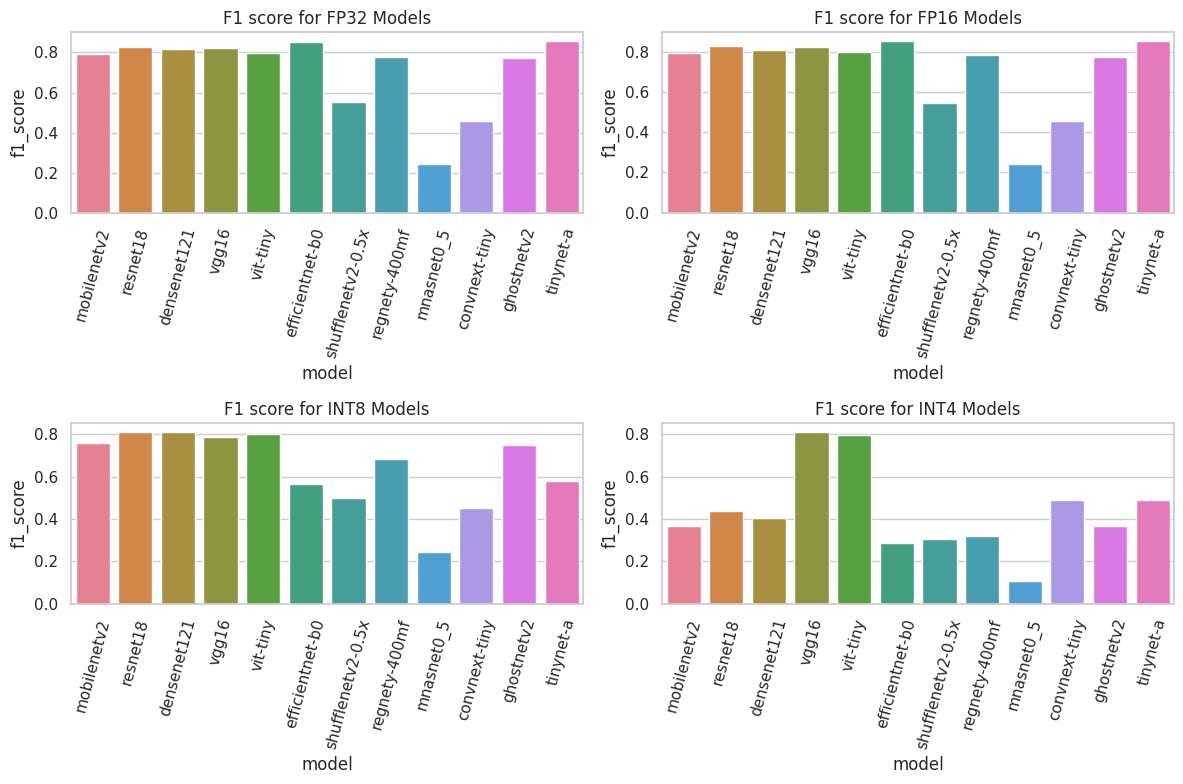

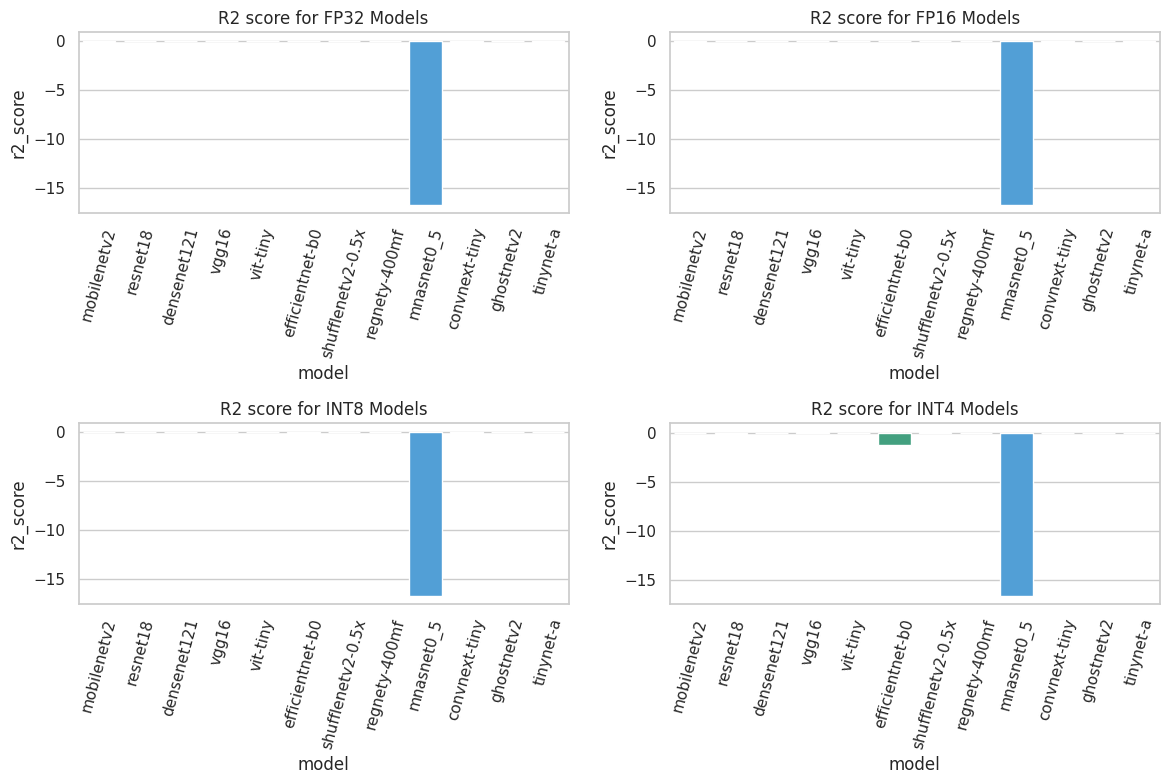

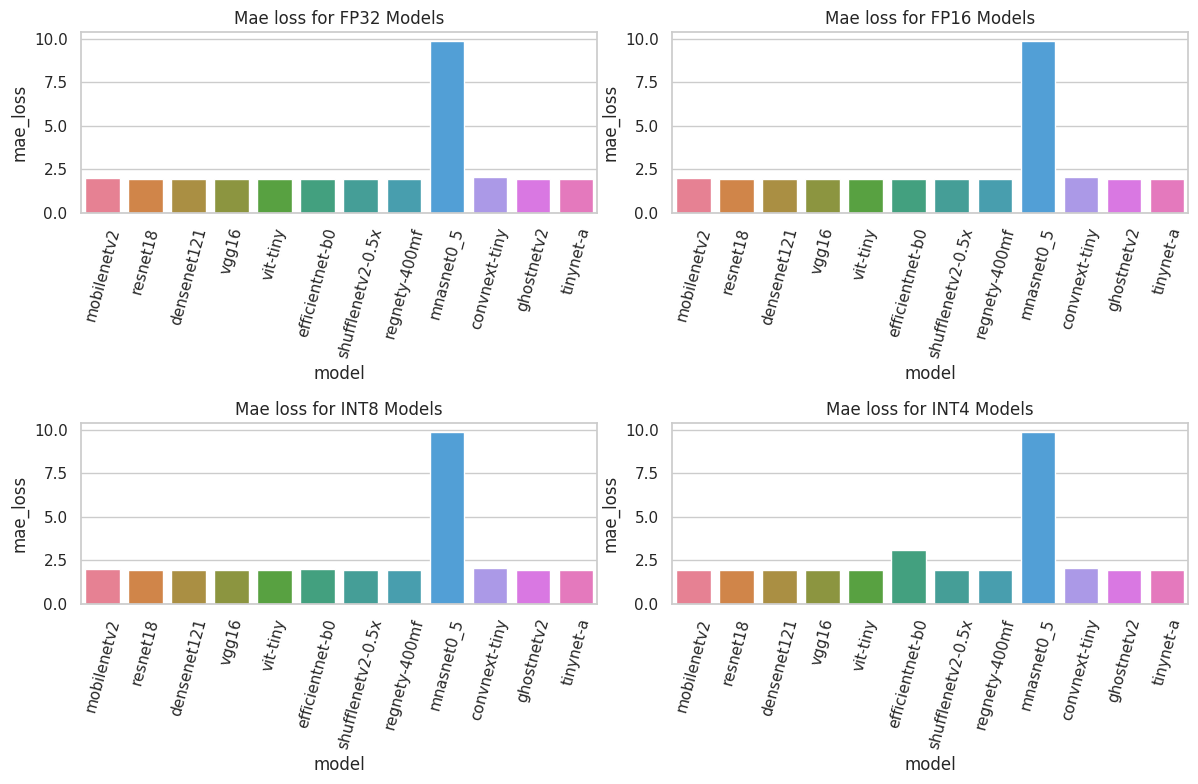

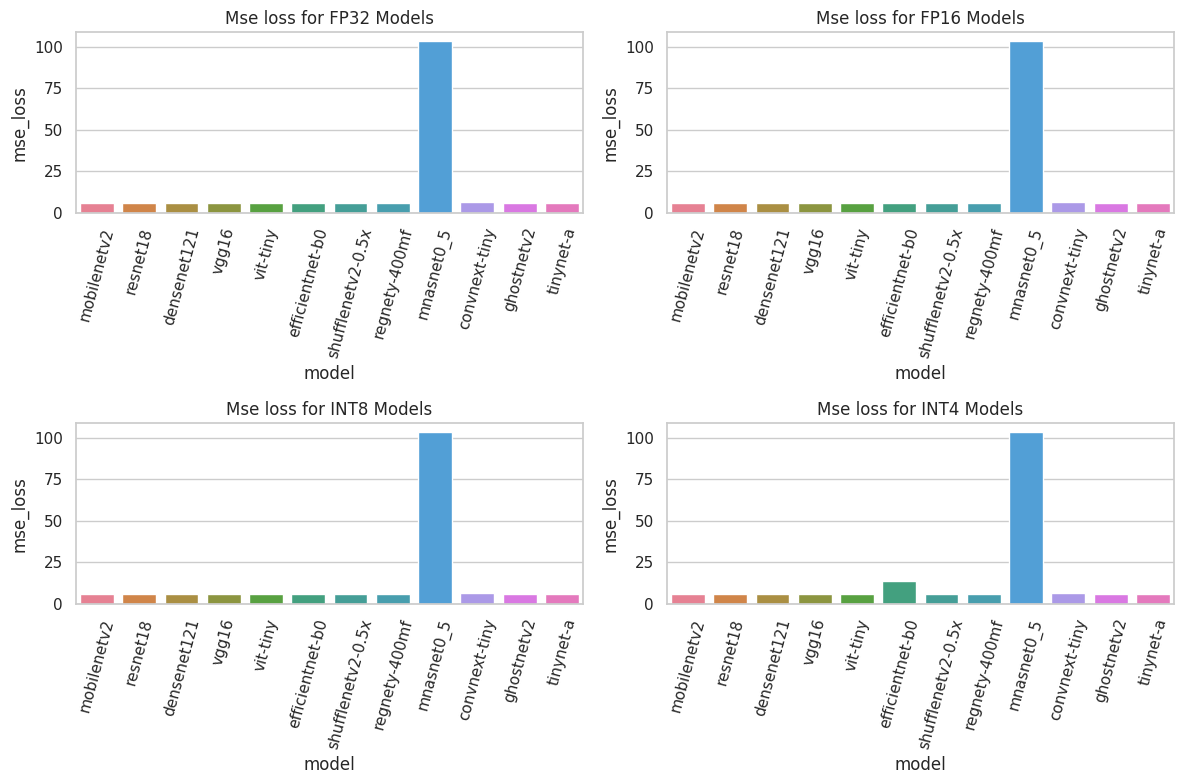

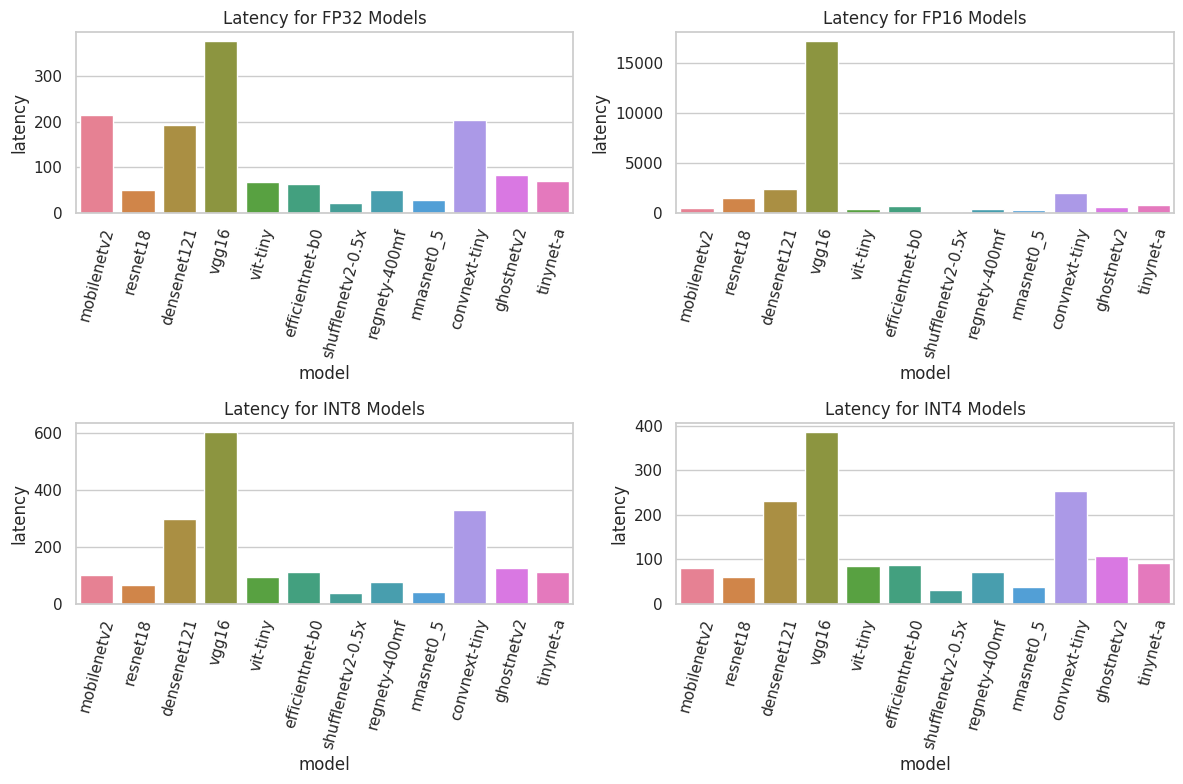

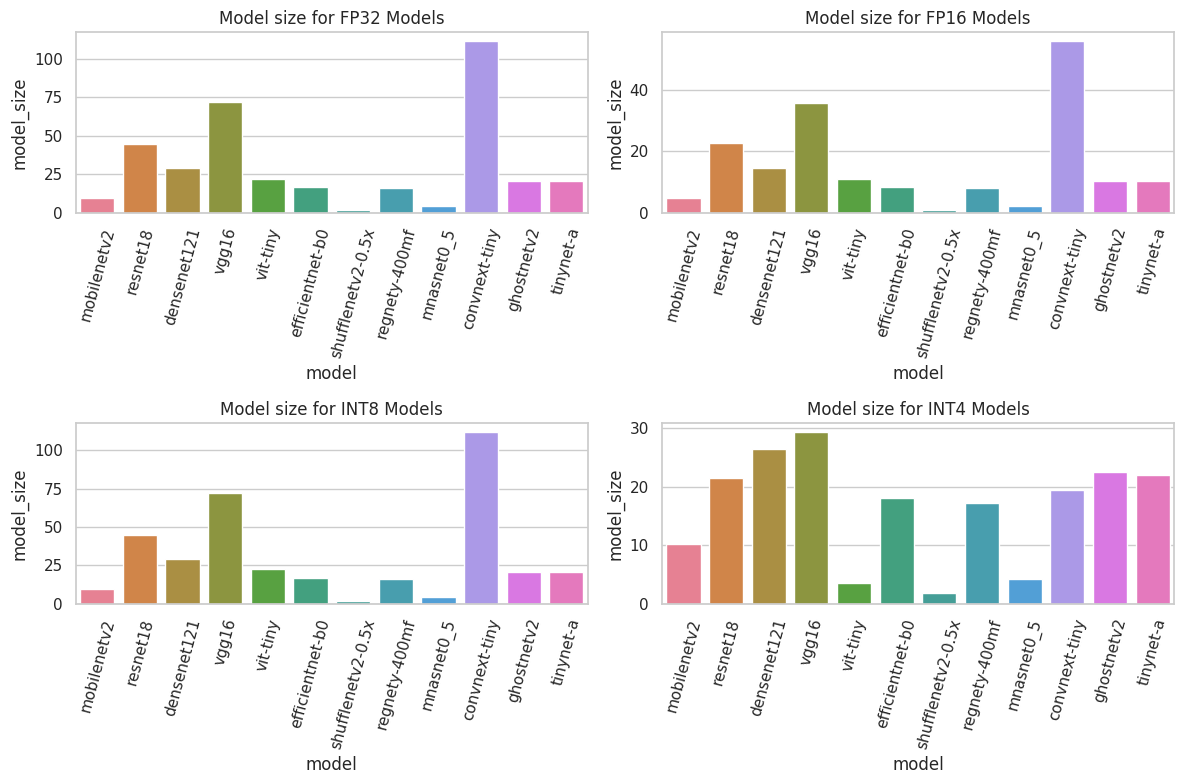

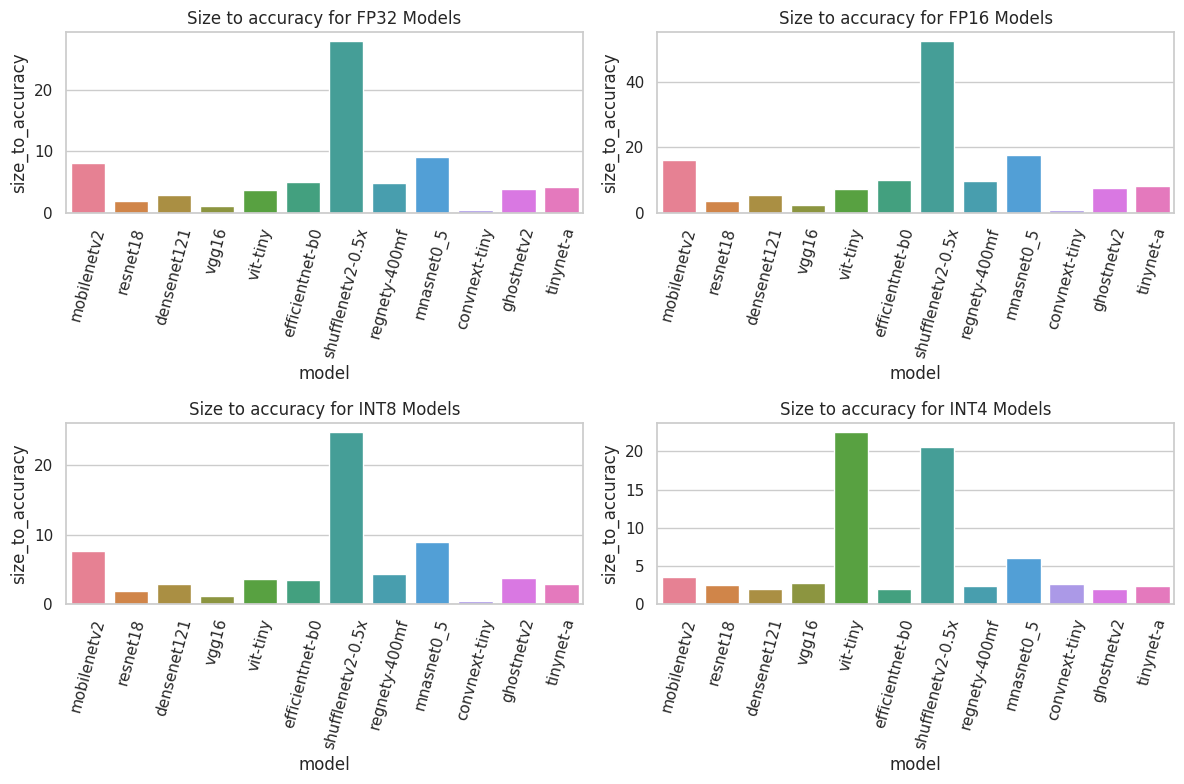

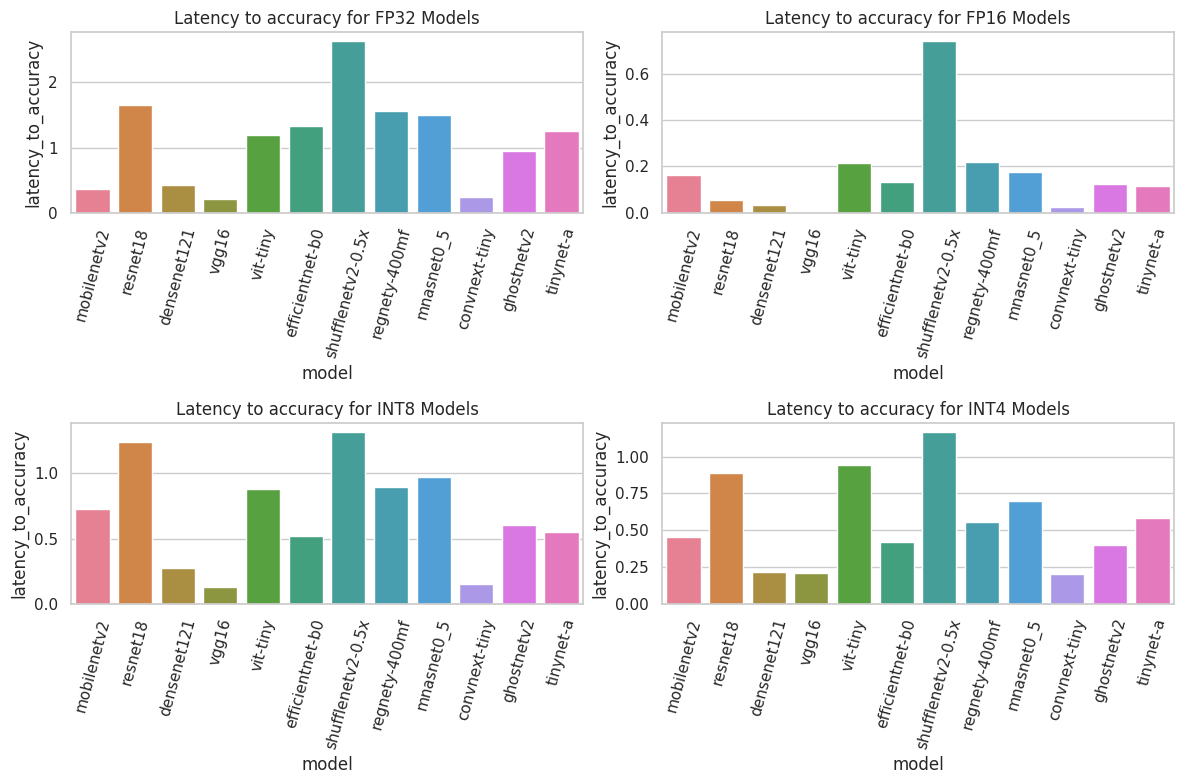

,model,bit-width,total_loss,cross_entropy_loss,accuracy,precision,recall,f1_score,r2_score,mae_loss,mse_loss,latency,model_size,size_to_accuracy,latency_to_accuracy
0,tinynet-a,fp32,2.045634,0.377457,0.859155,0.857417,0.859155,0.857446,-0.067230,1.946846,5.938046,68.969881,20.62,4.166610,1.245696
1,efficientnet-b0,fp32,2.039977,0.372367,0.852113,0.853521,0.852113,0.852746,-0.024057,1.945587,5.931068,64.059193,16.97,5.021289,1.330196
2,tinynet-a,fp16,2.045898,0.377637,0.852113,0.849638,0.852113,0.850447,-0.067526,1.946680,5.938281,743.144403,10.38,8.209178,0.114663
3,efficientnet-b0,fp16,2.039844,0.372412,0.852113,0.853521,0.852113,0.852746,-0.024478,1.945117,5.930469,646.807733,8.54,9.977900,0.131741
4,resnet18,fp32,2.053102,0.410280,0.830986,0.832201,0.830986,0.826620,0.015064,1.934186,5.886355,50.497228,45.04,1.844995,1.645607
5,resnet18,fp16,2.052930,0.409912,0.830986,0.832201,0.830986,0.826620,0.014703,1.934180,5.886719,1517.653101,22.54,3.686717,0.054755
6,vgg16,fp32,2.028804,0.373629,0.823944,0.825069,0.823944,0.822978,0.067526,1.932233,5.890878,377.274857,71.72,1.148834,0.218393
7,vgg16,fp16,2.028125,0.373486,0.823944,0.825069,0.823944,0.822978,0.067503,1.931836,5.889062,17158.237695,35.86,2.297668,0.004802
8,densenet121,fp32,2.031694,0.372776,0.816901,0.818316,0.816901,0.816969,-0.009183,1.937412,5.902500,193.436826,28.90,2.826648,0.422309
9,vgg16,int4,2.091795,0.449271,0.816901,0.814007,0.816901,0.811741,0.126331,1.943603,5.924352,386.273059,29.38,2.780468,0.211483


In [110]:
# Define the metrics to compare
metrics = ["total_loss", "cross_entropy_loss", "accuracy", "precision", "recall", "f1_score", "r2_score", "mae_loss", "mse_loss", "latency", "model_size","size_to_accuracy", "latency_to_accuracy"]

bit_widths = ["fp32", "fp16", "int8", "int4"]

# Set up visualization
sns.set(style="whitegrid")

for metric in metrics:

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # Create 2x2 subplots
    for i, bit_width in enumerate(bit_widths):
        ax = axes[i // 2, i % 2]  # Arrange in 2x2 grid
        subset = dfs_infer_ptq[dfs_infer_ptq["bit-width"] == bit_width]
        
        sns.barplot(data=subset, x="model", y=metric, ax=ax, hue="model")
        ax.set_title(f"{metric.replace("_", " ").capitalize()} for {bit_width.upper()} Models")
        ax.tick_params(axis="x", rotation=75)  # Rotate x-axis labels correctly

    plt.tight_layout()
    plt.show()

# Generate statistics summary
summary = dfs_infer_ptq.groupby(["model", "bit-width"])[metrics].mean().sort_values("accuracy", ascending=False).reset_index()
display(summary)